# Version 2: Adding more input and output features like age, gender, ados scores, etc

In [19]:
# ========================
# Multi-Task ADOS Prediction: Severity, Age, Gender, Social Affect, RRB, Comparison Score
# ========================
import numpy as np
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ========================
# 1. Enhanced preprocessing
# ========================
def load_npz_sequence(folder_path):
    frame_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    sequence = []
    for f in frame_files:
        data = np.load(os.path.join(folder_path, f))['coordinates']
        if data.shape[0] > 0:
            person_data = data[0]
            sequence.append(person_data)
    if not sequence:
        return np.empty((0, 24, 2))
    return np.array(sequence)

def normalize_skeleton(sequence):
    """Improved normalization with stability"""
    if sequence.shape[0] == 0:
        return sequence
    
    # Center around hip midpoint
    center = (sequence[:, 8:9, :] + sequence[:, 11:12, :]) / 2
    sequence = sequence - center
    
    # Normalize by torso length for scale invariance
    torso_length = np.linalg.norm(
        sequence[:, 1, :] - (sequence[:, 8, :] + sequence[:, 11, :]) / 2,
        axis=1, keepdims=True
    )
    torso_length = np.maximum(torso_length, 1e-6)  # Avoid division by zero
    sequence = sequence / (torso_length[:, :, np.newaxis] + 1e-6)
    
    return sequence

def pad_sequence(seq, max_len=100):
    num_frames, num_joints, _ = seq.shape
    if num_frames >= max_len:
        return seq[:max_len]
    else:
        pad_len = max_len - num_frames
        padding = np.zeros((pad_len, num_joints, 2))
        return np.concatenate([seq, padding], axis=0)

def compute_enhanced_features(sequence):
    """
    Enhanced feature extraction with more behavioral signals
    """
    num_frames = sequence.shape[0]
    
    # 1. Flattened joint positions (48 features)
    flat_joints = sequence.reshape(num_frames, -1)
    
    # 2. Velocity (48 features)
    velocity = np.zeros_like(flat_joints)
    velocity[1:] = flat_joints[1:] - flat_joints[:-1]
    
    # 3. Acceleration (48 features)
    acceleration = np.zeros_like(flat_joints)
    acceleration[1:] = velocity[1:] - velocity[:-1]
    
    # 4. Key joint distances (behavioral indicators)
    # Hand-hand distance
    left_wrist = sequence[:, 7, :]
    right_wrist = sequence[:, 4, :]
    dist_hands = np.linalg.norm(left_wrist - right_wrist, axis=1, keepdims=True)
    
    # Elbow-elbow distance
    left_elbow = sequence[:, 6, :]
    right_elbow = sequence[:, 3, :]
    dist_elbows = np.linalg.norm(left_elbow - right_elbow, axis=1, keepdims=True)
    
    # Hand-to-body distances (self-stimulatory behaviors)
    neck = sequence[:, 1, :]
    dist_left_hand_body = np.linalg.norm(left_wrist - neck, axis=1, keepdims=True)
    dist_right_hand_body = np.linalg.norm(right_wrist - neck, axis=1, keepdims=True)
    
    # 5. Movement magnitude (overall activity level)
    movement_mag = np.linalg.norm(velocity.reshape(num_frames, -1), axis=1, keepdims=True)
    
    # 6. Symmetry features (left-right coordination)
    left_shoulder = sequence[:, 5, :]
    right_shoulder = sequence[:, 2, :]
    shoulder_symmetry = np.linalg.norm(
        (left_wrist - left_shoulder) - (right_wrist - right_shoulder),
        axis=1, keepdims=True
    )
    
    # Combine all features
    features = np.concatenate([
        flat_joints,           # 48
        velocity,              # 48
        acceleration,          # 48
        dist_hands,            # 1
        dist_elbows,           # 1
        dist_left_hand_body,   # 1
        dist_right_hand_body,  # 1
        movement_mag,          # 1
        shoulder_symmetry      # 1
    ], axis=1)
    
    return features


In [20]:
# ========================
# 2. Load dataset - Use age/gender as INPUT features, predict ADOS metrics
# ========================
root_folder = "/kaggle/input/2d-coordinates"
metadata_file = "/kaggle/input/ados-rating/ADOS_rating.xlsx"
max_len = 100

def convert_age_to_years(age_str):
    """
    Convert age from format like "5Y,10M" to decimal years
    Example: "5Y,10M" -> 5 + 10/12 = 5.833
             "8Y,0M" -> 8.0
             "3Y,6M" -> 3.5
    """
    try:
        # If already a number, return it
        if isinstance(age_str, (int, float)):
            return float(age_str)
        
        # Convert to string and clean
        age_str = str(age_str).strip()
        
        # Split by comma
        parts = age_str.split(',')
        
        years = 0
        months = 0
        
        for part in parts:
            part = part.strip().upper()
            if 'Y' in part:
                years = int(part.replace('Y', '').strip())
            elif 'M' in part:
                months = int(part.replace('M', '').strip())
        
        # Convert to decimal years
        decimal_age = years + (months / 12.0)
        return decimal_age
    
    except Exception as e:
        print(f"Warning: Could not convert age '{age_str}': {e}")
        return None


# Load metadata
df = pd.read_excel(metadata_file)

# Display available columns for verification
print("Available columns in ADOS rating file:")
print(df.columns.tolist())
print(f"\nDataset has {len(df)} patients")

# Map patient IDs to data
# Targets (to predict): Severity, Social Affect, RRB, Comparison Score
# Attributes (input features): Age, Gender
target_columns = {
    'severity': 'Severity of Autism  ',
    'age': 'Chronological Age',
    'gender': 'Gender',
    'social_affect': 'Social Affect Total ',
    'rrb': 'Restricted and Repetitive Behavior (RRB) Total',
    'comparison_score': 'ADOS Comparison Score (1-10) <5  not very autistic. ASD people usually fall 5-10. 8-10=Severe, 5-7=moderate, 1-4=mild',
    'overall_total': 'Overall Total '
}

# Create mappings
id_to_data = {}
for idx, row in df.iterrows():
    patient_id = row['ID#']
    age_value = convert_age_to_years(row[target_columns['age']])
    # Skip if age conversion failed
    if age_value is None:
        print("Skipped")
        continue
    id_to_data[patient_id] = {
        'severity': row[target_columns['severity']],
        'age': age_value,
        'gender': row[target_columns['gender']],
        'social_affect': row[target_columns['social_affect']],
        'rrb': row[target_columns['rrb']],
        'comparison_score': row[target_columns['comparison_score']],
        'overall_total': row[target_columns['overall_total']]
    }

# Encode gender (categorical variable) - will be used as input feature
gender_encoder = LabelEncoder()
all_genders = [data['gender'] for data in id_to_data.values() if pd.notna(data['gender'])]
gender_encoder.fit(all_genders)
print(f"\nGender encoding (as input feature): {dict(zip(gender_encoder.classes_, gender_encoder.transform(gender_encoder.classes_)))}")

# Load sequences and labels
sequence_features = []  # Skeletal features
demographic_features = []  # Age and gender
labels = []  # Only ADOS targets
sequence_lengths = []
valid_patient_ids = []

for action in os.listdir(root_folder):
    action_path = os.path.join(root_folder, action)
    if not os.path.isdir(action_path):
        continue
    for trial in os.listdir(action_path):
        trial_path = os.path.join(action_path, trial)
        if not os.path.isdir(trial_path):
            continue
        try:
            patient_id = int(trial.split('_')[1])
        except (IndexError, ValueError):
            continue
        if patient_id not in id_to_data:
            continue
        
        sequence = load_npz_sequence(trial_path)
        if sequence.shape[0] == 0:
            continue
        
        # Get data for this patient
        patient_data = id_to_data[patient_id]
        
        # Check for missing values
        if any(pd.isna(patient_data[k]) for k in patient_data.keys()):
            continue
        
        # Encode gender for use as input
        gender_encoded = gender_encoder.transform([patient_data['gender']])[0]
        age_value = patient_data['age']
        
        # Process sequence
        original_length = min(sequence.shape[0], max_len)
        sequence = normalize_skeleton(sequence)
        sequence = pad_sequence(sequence, max_len)
        features = compute_enhanced_features(sequence)
        
        # Store skeletal features
        sequence_features.append(features)
        
        # Store demographic features (age, gender) - will be concatenated to model input
        demographic_features.append([age_value, gender_encoded])
        
        # Create label vector: [severity, social_affect, rrb, comparison_score]
        label_vector = [
            patient_data['severity'],
            patient_data['social_affect'],
            patient_data['rrb'],
            patient_data['comparison_score']
        ]
        labels.append(label_vector)
        sequence_lengths.append(original_length)
        valid_patient_ids.append(patient_id)

sequence_features = np.array(sequence_features)
demographic_features = np.array(demographic_features)
labels = np.array(labels)
sequence_lengths = np.array(sequence_lengths)

print(f"\nSequence features shape: {sequence_features.shape}")
print(f"Demographic features shape: {demographic_features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Number of samples: {len(sequence_features)}")

# Print statistics
print("\n" + "="*70)
print("INPUT FEATURES (Demographics)")
print("="*70)

print(f"Age            - Mean: {demographic_features[:, 0].mean():6.2f}, Std: {demographic_features[:, 0].std():6.2f}")

print(f"Gender (0/1)   - Mean: {demographic_features[:, 1].mean():6.2f}, Distribution: {np.bincount(demographic_features[:, 1].astype(int))}")
print("="*70)
print(f"Min: {labels[:, i].min():6.2f}, Max: {labels[:, i].max():6.2f}")

print("\n" + "="*70)    
print(f"{name:20s} - Mean: {labels[:, i].mean():6.2f}, Std: {labels[:, i].std():6.2f}, ")

print("TARGET VARIABLES (ADOS Metrics)")
for i, name in enumerate(target_names):
    print("="*70)
    target_names = ['Severity of Autism  ', 'Social Affect Total ', 'Restricted and Repetitive Behavior (RRB) Total', 'ADOS Comparison Score (1-10) <5  not very autistic. ASD people usually fall 5-10. 8-10=Severe, 5-7=moderate, 1-4=mild']

Available columns in ADOS rating file:
['ID#', 'Gender', 'Chronological Age', 'Module', 'Social Affect Total ', 'Restricted and Repetitive Behavior (RRB) Total', 'Overall Total ', 'ADOS-2 classification/Dx', 'ADOS Comparison Score (1-10) <5  not very autistic. ASD people usually fall 5-10. 8-10=Severe, 5-7=moderate, 1-4=mild', 'Severity of Autism  ']

Dataset has 41 patients

Gender encoding (as input feature): {'F': 0, 'M': 1}

Sequence features shape: (1268, 100, 150)
Demographic features shape: (1268, 2)
Labels shape: (1268, 4)
Number of samples: 1268

INPUT FEATURES (Demographics)
Age            - Mean:   8.08, Std:   2.46
Gender (0/1)   - Mean:   0.73, Distribution: [347 921]


UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype('<U32'), dtype('<U32')) -> None

In [21]:
# Convert labels to numeric safely
labels = np.array(labels, dtype=object).astype(str)

clean_labels = []
for row in labels:
    clean_row = []
    for value in row:
        try:
            clean_value = float(value)
        except:
            # If string like '7*' or missing values → skip sample
            clean_value = None
        clean_row.append(clean_value)
    clean_labels.append(clean_row)

clean_labels = np.array(clean_labels, dtype=object)

# Remove rows with None
valid_mask = ~np.any(pd.isna(clean_labels).astype(bool), axis=1)
clean_labels = clean_labels[valid_mask]
sequence_features = sequence_features[valid_mask]
demographic_features = demographic_features[valid_mask]
sequence_lengths = sequence_lengths[valid_mask]

# Convert to float
labels = clean_labels.astype(float)
labels = np.array(labels)

In [22]:
# ========================
# 3. Feature normalization and target scaling
# ========================
# Normalize skeletal features
original_shape = sequence_features.shape
sequence_reshaped = sequence_features.reshape(-1, sequence_features.shape[-1])

feature_scaler = StandardScaler()
sequence_normalized = feature_scaler.fit_transform(sequence_reshaped)
sequence_features = sequence_normalized.reshape(original_shape)

# Normalize demographic features (age, gender)
demographic_scaler = StandardScaler()
demographic_features_normalized = demographic_scaler.fit_transform(demographic_features)

print("Feature scaling:")
print(f"  Skeletal features: StandardScaler applied")
print(f"  Age: StandardScaler applied (as input feature)")
print(f"  Gender: StandardScaler applied (as input feature)")

# Scale targets (all regression tasks now)
target_scalers = []
labels_scaled = np.zeros_like(labels)

# Targets: [severity, social_affect, rrb, comparison_score] - all need scaling
for i in range(labels.shape[1]):
    scaler = StandardScaler()
    labels_scaled[:, i] = scaler.fit_transform(labels[:, i].reshape(-1, 1)).flatten()
    target_scalers.append(scaler)

print("\nTarget scaling applied:")
print(f"  Severity: Scaled")
print(f"  Social Affect: Scaled")
print(f"  RRB: Scaled")
print(f"  Comparison Score: Scaled")

# Convert to torch tensors
X_sequence = torch.tensor(sequence_features, dtype=torch.float32)
X_demographic = torch.tensor(demographic_features_normalized, dtype=torch.float32)
y = torch.tensor(labels_scaled, dtype=torch.float32)
seq_lens = torch.tensor(sequence_lengths, dtype=torch.long)

# Store original labels for evaluation
y_original = torch.tensor(labels, dtype=torch.float32)

# Train/validation split
dataset = TensorDataset(X_sequence, X_demographic, y, y_original, seq_lens)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\nDataset split:")
print(f"  Training samples: {train_size}")
print(f"  Validation samples: {val_size}")
print(f"  Batch size: 32")


Feature scaling:
  Skeletal features: StandardScaler applied
  Age: StandardScaler applied (as input feature)
  Gender: StandardScaler applied (as input feature)

Target scaling applied:
  Severity: Scaled
  Social Affect: Scaled
  RRB: Scaled
  Comparison Score: Scaled

Dataset split:
  Training samples: 1014
  Validation samples: 254
  Batch size: 32


In [23]:
# ========================
# 4. Multi-Task ADOS Model with Demographic Input Features
# ========================
class ImprovedADOSModel(nn.Module):
    def __init__(self, sequence_input_size, demographic_input_size=2, 
                 hidden_size=128, num_layers=2, dropout=0.4, num_outputs=4):
        super(ImprovedADOSModel, self).__init__()
        
        self.num_outputs = num_outputs
        self.demographic_input_size = demographic_input_size
        
        # Bidirectional LSTM for sequence processing (shared for all tasks)
        self.lstm = nn.LSTM(
            sequence_input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True, 
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Attention mechanism (shared)
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        
        # Layer normalization
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        
        # Demographic feature processing
        self.demographic_fc = nn.Sequential(
            nn.Linear(demographic_input_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        
        # Shared representation layer (combines sequence + demographic)
        combined_size = hidden_size * 2 + 16
        self.shared_fc = nn.Sequential(
            nn.Linear(combined_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Task-specific heads (all regression)
        # Output 0: Severity
        self.severity_head = nn.Linear(64, 1)
        
        # Output 1: Social Affect
        self.social_affect_head = nn.Linear(64, 1)
        
        # Output 2: RRB
        self.rrb_head = nn.Linear(64, 1)
        
        # Output 3: Comparison Score
        self.comparison_head = nn.Linear(64, 1)
    
    def forward(self, x_sequence, x_demographic, seq_lengths=None):
        # LSTM processing for sequence data
        lstm_out, _ = self.lstm(x_sequence)
        
        # Apply layer normalization
        lstm_out = self.layer_norm(lstm_out)
        
        # Attention mechanism
        attention_weights = self.attention(lstm_out)
        attention_weights = torch.softmax(attention_weights, dim=1)
        
        # Weighted sum of sequence features
        sequence_context = torch.sum(attention_weights * lstm_out, dim=1)
        
        # Process demographic features
        demographic_repr = self.demographic_fc(x_demographic)
        
        # Combine sequence and demographic representations
        combined = torch.cat([sequence_context, demographic_repr], dim=1)
        
        # Shared representation
        shared_repr = self.shared_fc(combined)
        
        # Task-specific predictions
        severity = self.severity_head(shared_repr)
        social_affect = self.social_affect_head(shared_repr)
        rrb = self.rrb_head(shared_repr)
        comparison = self.comparison_head(shared_repr)
        
        # Concatenate outputs: [batch, 4]
        outputs = torch.cat([severity, social_affect, rrb, comparison], dim=1)
        
        return outputs

print("Multi-Task Model Architecture:")
print("  Input: Sequence features (150 per frame) + Demographic features (age, gender)")
print("  Shared: Bidirectional LSTM + Attention + Demographic FC + Combined FC")
print("  Task-specific heads (all regression):")
print("    - Severity")
print("    - Social Affect")
print("    - RRB")
print("    - Comparison Score")
print("  Demographic features used as AUXILIARY INPUT to improve predictions")


Multi-Task Model Architecture:
  Input: Sequence features (150 per frame) + Demographic features (age, gender)
  Shared: Bidirectional LSTM + Attention + Demographic FC + Combined FC
  Task-specific heads (all regression):
    - Severity
    - Social Affect
    - RRB
    - Comparison Score
  Demographic features used as AUXILIARY INPUT to improve predictions


In [24]:
# ========================
# 5. Multi-Task Training with Weighted Loss (4 ADOS Metrics)
# ========================
sequence_input_size = sequence_features.shape[2]
demographic_input_size = demographic_features.shape[1]

model = ImprovedADOSModel(
    sequence_input_size=sequence_input_size,
    demographic_input_size=demographic_input_size,
    hidden_size=128,
    num_layers=2,
    dropout=0.4,
    num_outputs=4
)

# Multi-task loss function (4 regression tasks)
def multi_task_loss(predictions, targets, task_weights=None):
    """
    Compute weighted multi-task loss for 4 ADOS metrics
    predictions: [batch, 4]
    targets: [batch, 4]
    
    Task breakdown:
    - 0: Severity (Huber Loss)
    - 1: Social Affect (Huber Loss)
    - 2: RRB (Huber Loss)
    - 3: Comparison Score (Huber Loss)
    """
    if task_weights is None:
        # Default weights (can be tuned based on importance)
        task_weights = {
            'severity': 1.5,
            'social_affect': 1.3,
            'rrb': 1.3,
            'comparison': 1.0
        }
    
    # Huber loss for robustness to outliers
    huber = nn.HuberLoss(delta=1.0)
    
    loss_severity = huber(predictions[:, 0], targets[:, 0])
    loss_social_affect = huber(predictions[:, 1], targets[:, 1])
    loss_rrb = huber(predictions[:, 2], targets[:, 2])
    loss_comparison = huber(predictions[:, 3], targets[:, 3])
    
    # Weighted total loss
    total_loss = (
        task_weights['severity'] * loss_severity +
        task_weights['social_affect'] * loss_social_affect +
        task_weights['rrb'] * loss_rrb +
        task_weights['comparison'] * loss_comparison
    )
    
    # Return total loss and individual losses for monitoring
    losses_dict = {
        'total': total_loss,
        'severity': loss_severity,
        'social_affect': loss_social_affect,
        'rrb': loss_rrb,
        'comparison': loss_comparison
    }
    
    return total_loss, losses_dict

# Optimizer with weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

# Early stopping
best_val_loss = float('inf')
patience = 15
patience_counter = 0

num_epochs = 100

print("\n" + "="*70)
print("STARTING MULTI-TASK TRAINING (4 ADOS METRICS)")
print("="*70)
print(f"Epochs: {num_epochs}")
print(f"Learning rate: 1e-3")
print(f"Early stopping patience: {patience}")
print(f"Using Age and Gender as INPUT features to improve predictions")
print("="*70 + "\n")

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    train_losses_sum = {k: 0.0 for k in ['severity', 'social_affect', 'rrb', 'comparison']}
    
    for x_seq, x_demo, yb, yb_orig, lens in train_loader:
        optimizer.zero_grad()
        out = model(x_seq, x_demo, lens)
        loss, losses_dict = multi_task_loss(out, yb)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * x_seq.size(0)
        for k in train_losses_sum.keys():
            train_losses_sum[k] += losses_dict[k].item() * x_seq.size(0)
    
    train_loss /= len(train_loader.dataset)
    for k in train_losses_sum.keys():
        train_losses_sum[k] /= len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_loss = 0
    val_losses_sum = {k: 0.0 for k in ['severity', 'social_affect', 'rrb', 'comparison']}
    
    with torch.no_grad():
        for x_seq, x_demo, yb, yb_orig, lens in val_loader:
            out = model(x_seq, x_demo, lens)
            loss, losses_dict = multi_task_loss(out, yb)
            
            val_loss += loss.item() * x_seq.size(0)
            for k in val_losses_sum.keys():
                val_losses_sum[k] += losses_dict[k].item() * x_seq.size(0)
    
    val_loss /= len(val_loader.dataset)
    for k in val_losses_sum.keys():
        val_losses_sum[k] /= len(val_loader.dataset)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Task Losses (Val):")
        print(f"    Severity: {val_losses_sum['severity']:.4f}")
        print(f"    Social Affect: {val_losses_sum['social_affect']:.4f}")
        print(f"    RRB: {val_losses_sum['rrb']:.4f}")
        print(f"    Comparison: {val_losses_sum['comparison']:.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_ados_multitask_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load('best_ados_multitask_model.pth'))
print("\n✅ Best model loaded")


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



STARTING MULTI-TASK TRAINING (4 ADOS METRICS)
Epochs: 100
Learning rate: 1e-3
Early stopping patience: 15
Using Age and Gender as INPUT features to improve predictions

Epoch 1/100
  Train Loss: 1.8729 | Val Loss: 1.9127
  Task Losses (Val):
    Severity: 0.4150
    Social Affect: 0.3961
    RRB: 0.2648
    Comparison: 0.4311
Epoch 5/100
  Train Loss: 1.1760 | Val Loss: 1.0948
  Task Losses (Val):
    Severity: 0.1902
    Social Affect: 0.2358
    RRB: 0.2152
    Comparison: 0.2232
Epoch 10/100
  Train Loss: 0.7693 | Val Loss: 0.9246
  Task Losses (Val):
    Severity: 0.2235
    Social Affect: 0.1754
    RRB: 0.1169
    Comparison: 0.2093
Epoch 15/100
  Train Loss: 0.6027 | Val Loss: 0.6087
  Task Losses (Val):
    Severity: 0.1519
    Social Affect: 0.1177
    RRB: 0.0692
    Comparison: 0.1377
Epoch 20/100
  Train Loss: 0.4267 | Val Loss: 0.5660
  Task Losses (Val):
    Severity: 0.1342
    Social Affect: 0.1124
    RRB: 0.0682
    Comparison: 0.1301
Epoch 25/100
  Train Loss: 0.355

In [26]:
# ========================
# 6. Comprehensive Evaluation Metrics (4 ADOS Tasks)
# ========================
model.eval()

# Collect predictions and targets
all_preds = []
all_targets_scaled = []
all_targets_original = []
all_demographics = []

with torch.no_grad():
    for x_seq, x_demo, yb_scaled, yb_orig, lens in val_loader:
        out = model(x_seq, x_demo, lens)
        all_preds.append(out.numpy())
        all_targets_scaled.append(yb_scaled.numpy())
        all_targets_original.append(yb_orig.numpy())
        all_demographics.append(x_demo.numpy())

# Concatenate all batches
preds_scaled = np.concatenate(all_preds, axis=0)
targets_scaled = np.concatenate(all_targets_scaled, axis=0)
targets_original = np.concatenate(all_targets_original, axis=0)
demographics_scaled = np.concatenate(all_demographics, axis=0)

# Convert predictions back to original scale
preds_original = np.zeros((preds_scaled.shape[0], 4))

# All 4 outputs are regression tasks
for i in range(4):
    preds_original[:, i] = target_scalers[i].inverse_transform(preds_scaled[:, i].reshape(-1, 1)).flatten()

# Inverse transform demographics for display
demographics_original = demographic_scaler.inverse_transform(demographics_scaled)

# Calculate metrics for each task
target_names = ['Severity', 'Social Affect', 'RRB', 'Comparison Score']

print("\n" + "="*80)
print("FINAL VALIDATION METRICS - 4 ADOS PREDICTIONS")
print("="*80)
print("Using Age and Gender as INPUT features (not predicted)")
print("="*80)

for i, name in enumerate(target_names):
    y_true = targets_original[:, i]
    y_pred = preds_original[:, i]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Calculate relative error
    mean_true = np.mean(y_true)
    relative_mae = (mae / mean_true) * 100 if mean_true != 0 else float('inf')
    
    print(f"\n{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  Relative MAE: {relative_mae:.2f}%")
    print(f"  Mean True Value: {mean_true:.2f}")

print("\n" + "="*80)

# Overall summary
print("\nOVERALL PERFORMANCE SUMMARY:")
print("-" * 80)

avg_r2 = np.mean([r2_score(targets_original[:, i], preds_original[:, i]) for i in range(4)])
avg_mae_percent = np.mean([
    (mean_absolute_error(targets_original[:, i], preds_original[:, i]) / np.mean(targets_original[:, i])) * 100
    for i in range(4) if np.mean(targets_original[:, i]) != 0
])

print(f"  Average R² (all tasks): {avg_r2:.4f}")
print(f"  Average Relative MAE: {avg_mae_percent:.2f}%")

print("\n" + "="*80)
print("DEMOGRAPHIC FEATURES (used as input):")
print(f"  Age - Mean: {demographics_original[:, 0].mean():.2f}, Std: {demographics_original[:, 0].std():.2f}")
print(f"  Gender - Distribution: {np.bincount(demographics_original[:, 1].astype(int))}")
print("="*80)

# Save predictions for further analysis
results_df = pd.DataFrame({
    'Severity_True': targets_original[:, 0],
    'Severity_Pred': preds_original[:, 0],
    'SocialAffect_True': targets_original[:, 1],
    'SocialAffect_Pred': preds_original[:, 1],
    'RRB_True': targets_original[:, 2],
    'RRB_Pred': preds_original[:, 2],
    'ComparisonScore_True': targets_original[:, 3],
    'ComparisonScore_Pred': preds_original[:, 3],
    'Age_Input': demographics_original[:, 0],
    'Gender_Input': demographics_original[:, 1]
})

results_df.to_csv('multitask_predictions.csv', index=False)
print("\n✅ Predictions saved to 'multitask_predictions.csv'")



FINAL VALIDATION METRICS - 4 ADOS PREDICTIONS
Using Age and Gender as INPUT features (not predicted)

Severity:
  MAE:  0.0628
  RMSE: 0.1608
  R²:   0.8514
  Relative MAE: 2.26%
  Mean True Value: 2.78

Social Affect:
  MAE:  1.6882
  RMSE: 2.5105
  R²:   0.7969
  Relative MAE: 9.90%
  Mean True Value: 17.06

RRB:
  MAE:  0.9390
  RMSE: 1.3841
  R²:   0.9141
  Relative MAE: 16.39%
  Mean True Value: 5.73

Comparison Score:
  MAE:  0.3718
  RMSE: 0.6386
  R²:   0.7795
  Relative MAE: 4.21%
  Mean True Value: 8.83


OVERALL PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------
  Average R² (all tasks): 0.8355
  Average Relative MAE: 8.19%

DEMOGRAPHIC FEATURES (used as input):
  Age - Mean: 8.15, Std: 2.57
  Gender - Distribution: [ 72 182]

✅ Predictions saved to 'multitask_predictions.csv'


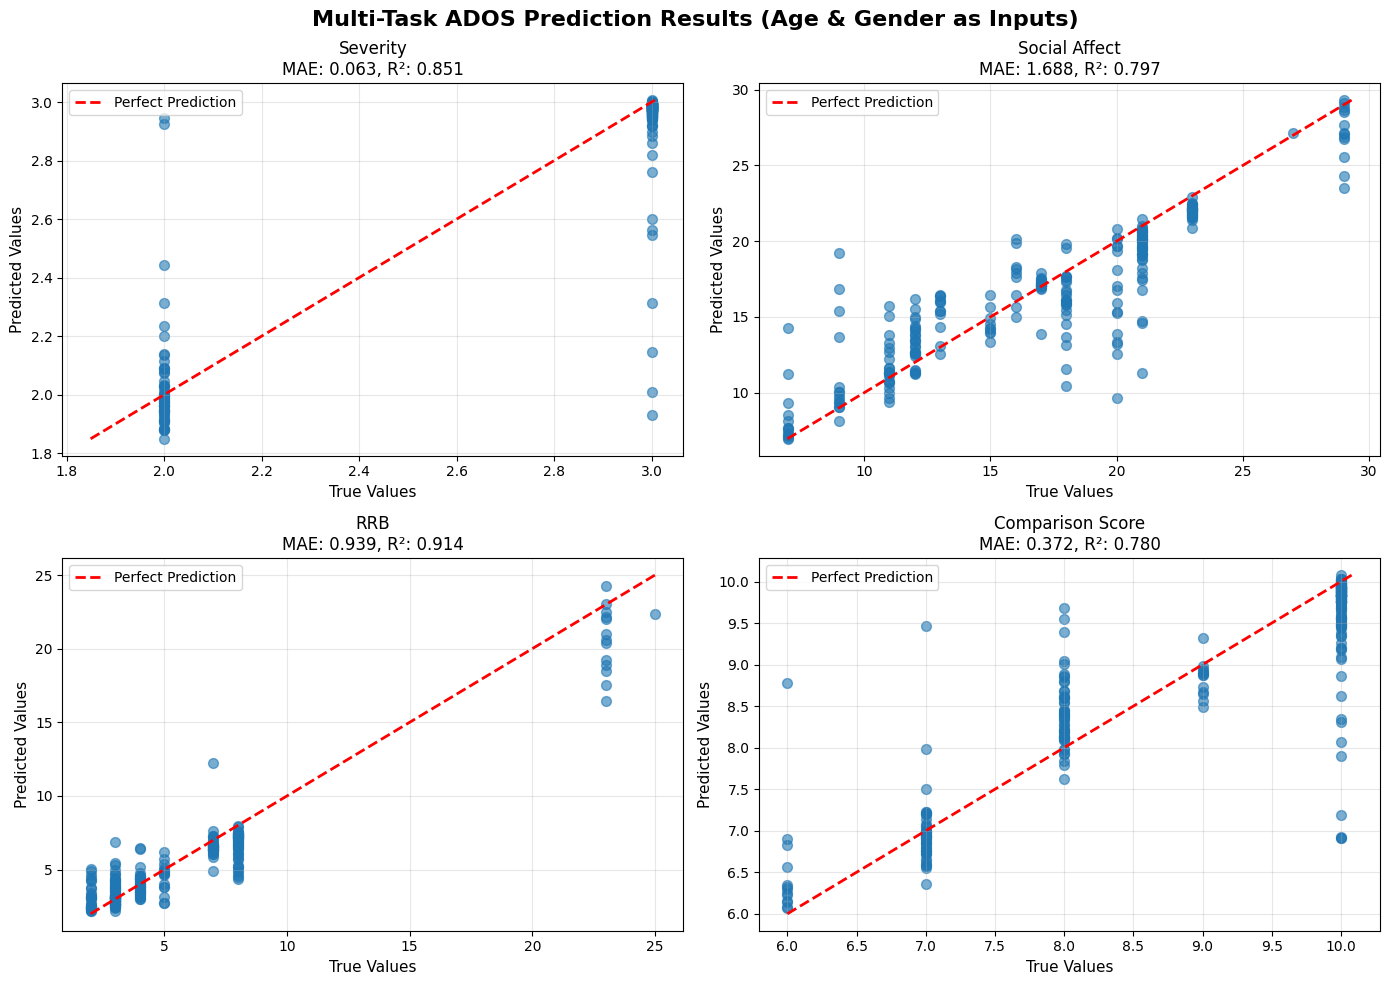

✅ Visualization saved to 'multitask_results.png'


In [27]:
# ========================
# 7. Visualization of Multi-Task Results (4 ADOS Metrics)
# ========================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multi-Task ADOS Prediction Results (Age & Gender as Inputs)', fontsize=16, fontweight='bold')

task_names_plot = ['Severity', 'Social Affect', 'RRB', 'Comparison Score']

for idx, task_name in enumerate(task_names_plot):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    y_true = targets_original[:, idx]
    y_pred = preds_original[:, idx]
    
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.6, s=50)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    ax.set_xlabel('True Values', fontsize=11)
    ax.set_ylabel('Predicted Values', fontsize=11)
    ax.set_title(f'{task_name}\nMAE: {mae:.3f}, R²: {r2:.3f}', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multitask_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved to 'multitask_results.png'")


In [28]:
# ========================
# 8. Multi-Task Explainability for 4 ADOS Metrics
# Using Integrated Gradients + Feature Ablation
# ========================
import numpy as np
import json
import torch
import torch.nn as nn
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt

# ========================
# Joint Names Mapping (COCO format)
# ========================
COCO_JOINTS = [
    "nose", "neck", "right_shoulder", "right_elbow", "right_wrist",
    "left_shoulder", "left_elbow", "left_wrist", "right_hip", "right_knee",
    "right_ankle", "left_hip", "left_knee", "left_ankle", "right_eye",
    "left_eye", "right_ear", "left_ear", "pelvis", "thorax",
    "upper_neck", "head_top", "right_big_toe", "left_big_toe"
]

# ========================
# Multi-Task Explainability Module
# ========================
class MultiTaskADOSExplainer:
    def __init__(self, model, target_scalers, demographic_scaler, fps=30, device='cpu'):
        """
        Initialize explainer for 4-task ADOS model with demographic inputs
        """
        self.model = model.to(device)
        self.device = device
        self.model.eval()
        self.target_scalers = target_scalers
        self.demographic_scaler = demographic_scaler
        self.baseline_sequence = None
        self.fps = fps
        
        self.target_names = ['Severity', 'Social Affect', 'RRB', 'Comparison Score']
    
    def compute_integrated_gradients(self, x_seq: torch.Tensor, x_demo: torch.Tensor,
                                     seq_len: torch.Tensor, task_idx: int = 0, 
                                     steps: int = 50) -> Tuple[np.ndarray, np.ndarray, float, float]:
        """
        Compute Integrated Gradients for a specific task
        Returns attributions for both sequence and demographic features
        """
        if x_seq.dim() == 2:
            x_seq = x_seq.unsqueeze(0)
        if x_demo.dim() == 1:
            x_demo = x_demo.unsqueeze(0)
        if seq_len.dim() == 0:
            seq_len = seq_len.unsqueeze(0)
        
        x_seq = x_seq.to(self.device)
        x_demo = x_demo.to(self.device)
        seq_len = seq_len.to(self.device)
        
        # Create baselines
        if self.baseline_sequence is None or self.baseline_sequence.shape != x_seq.shape:
            self.baseline_sequence = torch.zeros_like(x_seq).to(self.device)
        baseline_demo = torch.zeros_like(x_demo).to(self.device)
        
        # Get predictions
        with torch.no_grad():
            baseline_out = self.model(self.baseline_sequence, baseline_demo, seq_len)
            baseline_pred = baseline_out[0, task_idx].item()
            
            actual_out = self.model(x_seq, x_demo, seq_len)
            actual_pred = actual_out[0, task_idx].item()
        
        # Compute integrated gradients
        integrated_grads_seq = torch.zeros_like(x_seq)
        integrated_grads_demo = torch.zeros_like(x_demo)
        
        for step in range(steps):
            alpha = (step + 1) / steps
            interpolated_seq = self.baseline_sequence + alpha * (x_seq - self.baseline_sequence)
            interpolated_demo = baseline_demo + alpha * (x_demo - baseline_demo)
            
            interpolated_seq.requires_grad_(True)
            interpolated_demo.requires_grad_(True)
            
            output = self.model(interpolated_seq, interpolated_demo, seq_len)
            task_output = output[:, task_idx]
            
            self.model.zero_grad()
            task_output.sum().backward()
            
            integrated_grads_seq += interpolated_seq.grad
            integrated_grads_demo += interpolated_demo.grad
        
        # Average and scale
        integrated_grads_seq = integrated_grads_seq / steps
        integrated_grads_demo = integrated_grads_demo / steps
        
        attributions_seq = (x_seq - self.baseline_sequence) * integrated_grads_seq
        attributions_demo = (x_demo - baseline_demo) * integrated_grads_demo
        
        return (attributions_seq[0].cpu().detach().numpy(), 
                attributions_demo[0].cpu().detach().numpy(),
                actual_pred, baseline_pred)

    def compute_temporal_contributions(self, attributions_seq: np.ndarray, 
                                      seq_len: int, 
                                      window_size_seconds: float = 1.0) -> List[Dict]:
        """
        Analyze temporal contributions by aggregating frame attributions into time windows
        
        Args:
            attributions_seq: Frame-level attributions [num_frames, num_features]
            seq_len: Actual sequence length (excluding padding)
            window_size_seconds: Size of temporal window in seconds
            
        Returns:
            List of dictionaries with temporal segment contributions
        """
        # Only consider non-padded frames
        attributions_seq = attributions_seq[:seq_len, :]
        
        # Calculate window size in frames
        window_size_frames = int(window_size_seconds * self.fps)
        if window_size_frames < 1:
            window_size_frames = 1
        
        # Aggregate attributions per frame (sum absolute values across all features)
        frame_contributions = np.sum(np.abs(attributions_seq), axis=1)
        
        # Create temporal windows
        num_windows = int(np.ceil(seq_len / window_size_frames))
        temporal_segments = []
        
        for i in range(num_windows):
            start_frame = i * window_size_frames
            end_frame = min((i + 1) * window_size_frames, seq_len)
            
            # Time in seconds
            start_time = start_frame / self.fps
            end_time = end_frame / self.fps
            
            # Aggregate contributions for this window
            window_contribution = np.sum(frame_contributions[start_frame:end_frame])
            
            # Get mean attribution sign (positive or negative influence)
            window_raw_attribution = np.sum(attributions_seq[start_frame:end_frame, :])
            
            temporal_segments.append({
                'start_time': float(start_time),
                'end_time': float(end_time),
                'start_frame': int(start_frame),
                'end_frame': int(end_frame),
                'contribution': float(window_contribution),
                'influence_direction': 'positive' if window_raw_attribution > 0 else 'negative',
                'raw_attribution': float(window_raw_attribution)
            })
        
        # Sort by contribution magnitude
        temporal_segments = sorted(temporal_segments, 
                                  key=lambda x: abs(x['contribution']), 
                                  reverse=True)
        
        return temporal_segments
    
    def explain_all_tasks(self, x_seq: torch.Tensor, x_demo: torch.Tensor, 
                          seq_len: torch.Tensor = None) -> Dict:
        """Generate comprehensive explanation for all 4 tasks"""
        if x_seq.dim() == 2:
            x_seq = x_seq.unsqueeze(0)
        if x_demo.dim() == 1:
            x_demo = x_demo.unsqueeze(0)
        if seq_len is None:
            seq_len = torch.tensor([x_seq.shape[1]], dtype=torch.long)
        elif seq_len.dim() == 0:
            seq_len = seq_len.unsqueeze(0)
        
        seq_length = seq_len.item()
        video_length = seq_length / self.fps

        print(f"Computing explanations for 4 ADOS metrics (Video: {video_length:.1f}s)...")

        
        # Get all predictions
        with torch.no_grad():
            x_seq_device = x_seq.to(self.device)
            x_demo_device = x_demo.to(self.device)
            seq_len_device = seq_len.to(self.device)
            all_outputs = self.model(x_seq_device, x_demo_device, seq_len_device)
        
        # Convert to original scale
        predictions = {}
        for i, name in enumerate(self.target_names):
            pred_scaled = all_outputs[0, i].item()
            predictions[name.lower().replace(' ', '_')] = float(
                self.target_scalers[i].inverse_transform([[pred_scaled]])[0, 0]
            )
        
        # Get demographic values (original scale)
        demo_original = self.demographic_scaler.inverse_transform(x_demo.cpu().numpy())[0]
        predictions['age_input'] = float(demo_original[0])
        predictions['gender_input'] = int(demo_original[1])
        
        # Compute integrated gradients for all tasks
        print("Computing explanations for 4 ADOS metrics...")
        
        explanations_per_task = {}
        for task_idx in range(4):
            task_name = self.target_names[task_idx]
            print(f"  Analyzing {task_name}...")
            
            attr_seq, attr_demo, pred, baseline = self.compute_integrated_gradients(
                x_seq, x_demo, seq_len, task_idx
            )
            
            # Get top contributing joints
            joint_contributions = self._compute_joint_contributions(attr_seq, seq_length)
            top_joints_positive = sorted(
                [(j, c) for j, c in joint_contributions.items() if c > 0],
                key=lambda x: abs(x[1]), reverse=True
            )
            top_joints_negative = sorted(
                [(j, c) for j, c in joint_contributions.items() if c < 0],
                key=lambda x: abs(x[1]), reverse=True
            )
            
            # Compute temporal contributions
            temporal_segments = self.compute_temporal_contributions(
                attr_seq, seq_length, window_size_seconds=1.0
            )
            
            # Separate positive and negative temporal influences
            positive_segments = [s for s in temporal_segments if s['influence_direction'] == 'positive'][:5]
            negative_segments = [s for s in temporal_segments if s['influence_direction'] == 'negative'][:5]
            # Demographic contributions
            demo_contrib = {
                'age_contribution': float(attr_demo[0]),
                'gender_contribution': float(attr_demo[1])
            }
            
            explanations_per_task[task_name] = {
                'prediction': float(pred),
                'baseline': float(baseline),
                'joints': {
                    'positive_contributors': [
                        {'joint': j, 'contribution': float(c)} 
                        for j, c in top_joints_positive
                    ],
                    'negative_contributors': [
                        {'joint': j, 'contribution': float(c)} 
                        for j, c in top_joints_negative
                    ]
                },
                'temporal_segments': {
                    'positive_segments': positive_segments,
                    'negative_segments': negative_segments,
                    'all_segments': temporal_segments
                },
                'demographic_contributions': demo_contrib,
                'total_sequence_attribution': float(np.sum(np.abs(attr_seq))),
                'total_demographic_attribution': float(np.sum(np.abs(attr_demo)))
            }
        
        explanation = {
            'predictions': predictions,
            'video_metadata': {
                'duration_seconds': float(video_length),
                'num_frames': int(seq_length),
                'fps': self.fps
            },
            'task_explanations': explanations_per_task,
            'summary': self._generate_summary(predictions, explanations_per_task)
        }
        
        return explanation
    
    def _compute_joint_contributions(self, attributions: np.ndarray, seq_len: int) -> Dict[str, float]:
        """Aggregate contributions per joint"""
        attributions = attributions[:seq_len, :]
        joint_attrs = attributions[:, :48].reshape(seq_len, 24, 2)
        joint_contributions = np.sum(joint_attrs, axis=(0, 2))
        
        return {COCO_JOINTS[i]: float(joint_contributions[i]) for i in range(len(COCO_JOINTS))}
    
    def _generate_summary(self, predictions: Dict, task_explanations: Dict) -> str:
        """Generate human-readable summary"""
        summary = "Multi-Task ADOS Assessment (Using Age & Gender as Inputs):\\n\\n"
        
        summary += f"PREDICTIONS:\\n"
        summary += f"  Severity: {predictions['severity']:.1f}\\n"
        summary += f"  Social Affect: {predictions['social_affect']:.1f}\\n"
        summary += f"  RRB: {predictions['rrb']:.1f}\\n"
        summary += f"  Comparison Score: {predictions['comparison_score']:.1f}\\n\\n"
        
        summary += f"INPUT DEMOGRAPHICS:\\n"
        summary += f"  Age: {predictions['age_input']:.1f} years\\n"
        summary += f"  Gender: {predictions['gender_input']}\\n\\n"
        
        # Key findings
        for task_name in ['Severity', 'Social Affect', 'RRB', 'Comparison Score']:
            if task_name in task_explanations:
                exp = task_explanations[task_name]
                top_joint = exp['joints']['positive_contributors'][0] if exp['joints']['positive_contributors'] else {'joint': 'N/A', 'contribution': 0}
                top_time = exp['temporal_segments']['positive_segments'][0] if exp['temporal_segments']['positive_segments'] else None
                demo_total = sum(abs(v) for v in exp['demographic_contributions'].values())
                summary += f"{task_name}: Top joint={top_joint['joint']} ({top_joint['contribution']:+.2f}), "
                summary += f"Demographic impact={demo_total:.2f}\\n"
        
        return summary
    
    def visualize_explanation(self, explanation: Dict, save_path: str = None):
        """Visualize multi-task predictions and explanations"""
        fig = plt.figure(figsize=(18, 14))
        gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)
        
        preds = explanation['predictions']
        video_meta = explanation['video_metadata']
        
        preds = explanation['predictions']
        
        fig.suptitle(
            f"Multi-Task ADOS Prediction\\n"
            f"Age: {preds['age_input']:.0f} | Gender: {preds['gender_input']} | "
            f"Severity: {preds['severity']:.1f} | Social Affect: {preds['social_affect']:.1f}"
            f"Video: {video_meta['duration_seconds']:.1f}s ({video_meta['num_frames']} frames)",    
            fontsize=14, fontweight='bold'
        )
        
        # Plot 1: All predictions
        ax1 = fig.add_subplot(gs[0, :])
        pred_values = [preds['severity'], preds['social_affect'], preds['rrb'], preds['comparison_score']]
        pred_labels = ['Severity', 'Social\\nAffect', 'RRB', 'Comparison\\nScore']
        
        bars = ax1.bar(pred_labels, pred_values, color='steelblue', alpha=0.7)
        ax1.set_ylabel('Score')
        ax1.set_title('Predicted ADOS Metrics (Demographics as Inputs)')
        ax1.grid(axis='y', alpha=0.3)
        
        # Plots 2-9: Joint and temporal contributions for each task
        task_names = ['Severity', 'Social Affect', 'RRB']
        positions = [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (3, 2)]
        
        for task_idx, task_name in enumerate(task_names):
            # Joint contributions
            ax_joint = fig.add_subplot(gs[task_idx + 1, 0])
            task_exp = explanation['task_explanations'][task_name]
            
            all_joints = (task_exp['joints']['positive_contributors'][:3] + 
                         task_exp['joints']['negative_contributors'][:2])
            joints = [j['joint'] for j in all_joints]
            contribs = [j['contribution'] for j in all_joints]
            colors = ['#d62728' if c > 0 else '#2ca02c' for c in contribs]
            
            ax_joint.barh(joints, contribs, color=colors, alpha=0.7)
            ax_joint.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
            ax_joint.set_xlabel('Contribution')
            ax_joint.set_title(f'{task_name}: Top Joints\nPred={task_exp["prediction"]:.2f}', fontsize=10)
            ax_joint.invert_yaxis()
            
            # Temporal contributions
            ax_temporal = fig.add_subplot(gs[task_idx + 1, 1:])
            
            pos_segs = task_exp['temporal_segments']['positive_segments'][:5]
            neg_segs = task_exp['temporal_segments']['negative_segments'][:3]
            
            y_pos = 0
            for seg in pos_segs:
                width = seg['end_time'] - seg['start_time']
                ax_temporal.barh(y_pos, width, left=seg['start_time'], 
                               color='#d62728', alpha=0.6, height=0.8)
                ax_temporal.text(seg['start_time'] + width/2, y_pos, 
                               f"{seg['contribution']:.1f}", 
                               ha='center', va='center', fontsize=8)
                y_pos += 1
            
            y_neg = -1
            for seg in neg_segs:
                width = seg['end_time'] - seg['start_time']
                ax_temporal.barh(y_neg, width, left=seg['start_time'], 
                               color='#2ca02c', alpha=0.6, height=0.8)
                ax_temporal.text(seg['start_time'] + width/2, y_neg, 
                               f"{seg['contribution']:.1f}", 
                               ha='center', va='center', fontsize=8)
                y_neg -= 1
            
            ax_temporal.axhline(y=-0.5, color='black', linestyle='--', linewidth=0.5)
            ax_temporal.set_xlabel('Time (seconds)')
            ax_temporal.set_title(f'{task_name}: Critical Time Segments\n(Red=Problematic, Green=Strength)', fontsize=10)
            ax_temporal.set_xlim(0, video_meta['duration_seconds'])
            ax_temporal.set_ylim(y_neg - 1, y_pos)
            ax_temporal.grid(axis='x', alpha=0.3)
            
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✅ Visualization saved to {save_path}")
        
        plt.show()

print("✅ Multi-Task Explainability Module Ready (4 ADOS Metrics + Demographics)")

✅ Multi-Task Explainability Module Ready (4 ADOS Metrics + Demographics)



Generating Explanations for 3 samples...


SAMPLE 1/3
Age: 6.5, Gender: 0
Computing explanations for 4 ADOS metrics (Video: 1.7s)...
Computing explanations for 4 ADOS metrics...
  Analyzing Severity...
  Analyzing Social Affect...
  Analyzing RRB...
  Analyzing Comparison Score...
Multi-Task ADOS Assessment (Using Age & Gender as Inputs):\n\nPREDICTIONS:\n  Severity: 3.0\n  Social Affect: 17.1\n  RRB: 7.1\n  Comparison Score: 9.8\n\nINPUT DEMOGRAPHICS:\n  Age: 6.5 years\n  Gender: 0\n\nSeverity: Top joint=right_ear (+0.51), Demographic impact=0.28\nSocial Affect: Top joint=right_shoulder (+0.25), Demographic impact=0.25\nRRB: Top joint=neck (+0.10), Demographic impact=0.30\nComparison Score: Top joint=neck (+0.43), Demographic impact=0.45\n

Ground Truth vs Predictions:
  severity: True=3.00, Pred=2.98, Error=0.02
  social_affect: True=17.00, Pred=17.09, Error=0.09
  rrb: True=8.00, Pred=7.10, Error=0.90
  comparison_score: True=10.00, Pred=9.83, Error=0.17

TEMPORAL INSIGHTS (Critica

/tmp/ipykernel_47/1931286351.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Visualization saved to multitask_explanation_1.png


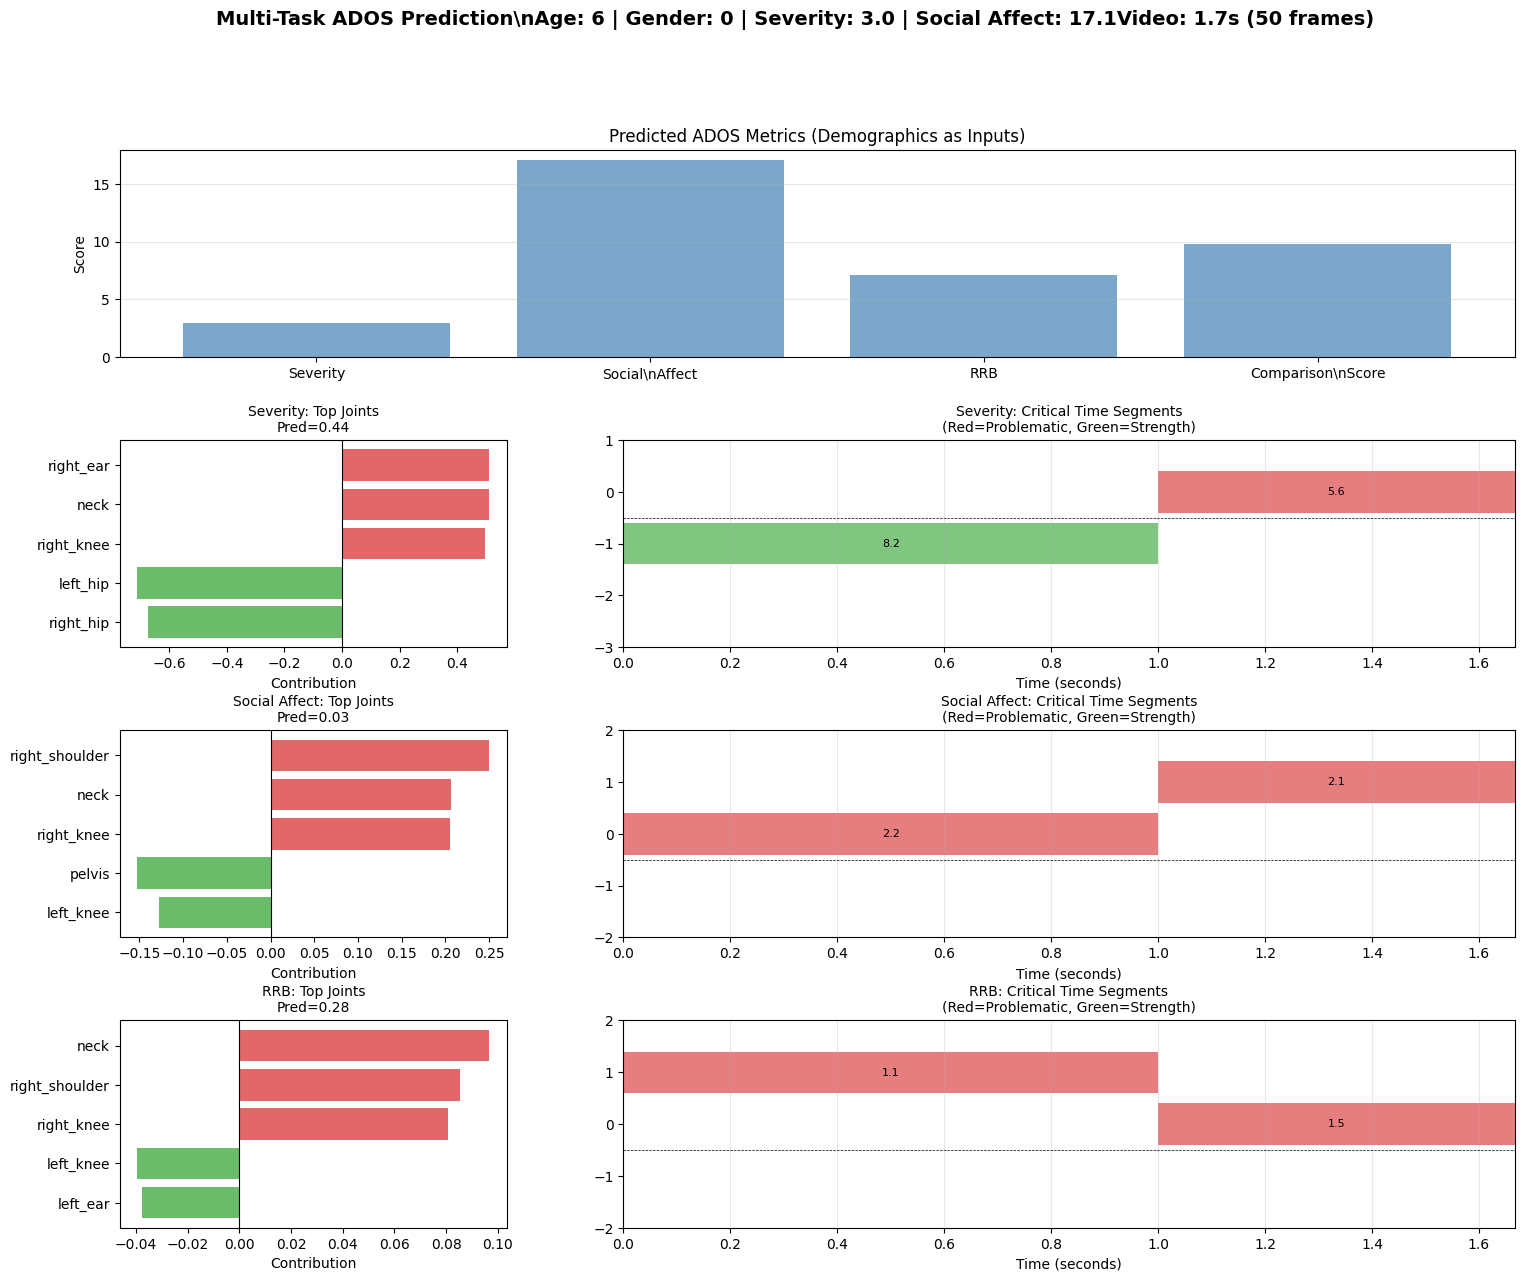


SAMPLE 2/3
Age: 6.5, Gender: 1
Computing explanations for 4 ADOS metrics (Video: 3.3s)...
Computing explanations for 4 ADOS metrics...
  Analyzing Severity...
  Analyzing Social Affect...
  Analyzing RRB...
  Analyzing Comparison Score...
Multi-Task ADOS Assessment (Using Age & Gender as Inputs):\n\nPREDICTIONS:\n  Severity: 3.0\n  Social Affect: 20.1\n  RRB: 4.4\n  Comparison Score: 9.8\n\nINPUT DEMOGRAPHICS:\n  Age: 6.5 years\n  Gender: 1\n\nSeverity: Top joint=left_hip (+0.19), Demographic impact=0.01\nSocial Affect: Top joint=right_hip (+0.56), Demographic impact=0.14\nRRB: Top joint=right_hip (+0.13), Demographic impact=0.06\nComparison Score: Top joint=right_hip (+0.48), Demographic impact=0.09\n

Ground Truth vs Predictions:
  severity: True=3.00, Pred=2.98, Error=0.02
  social_affect: True=21.00, Pred=20.06, Error=0.94
  rrb: True=4.00, Pred=4.36, Error=0.36
  comparison_score: True=10.00, Pred=9.82, Error=0.18

TEMPORAL INSIGHTS (Critical Time Segments):

Severity:
  Problema

/tmp/ipykernel_47/1931286351.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Visualization saved to multitask_explanation_2.png


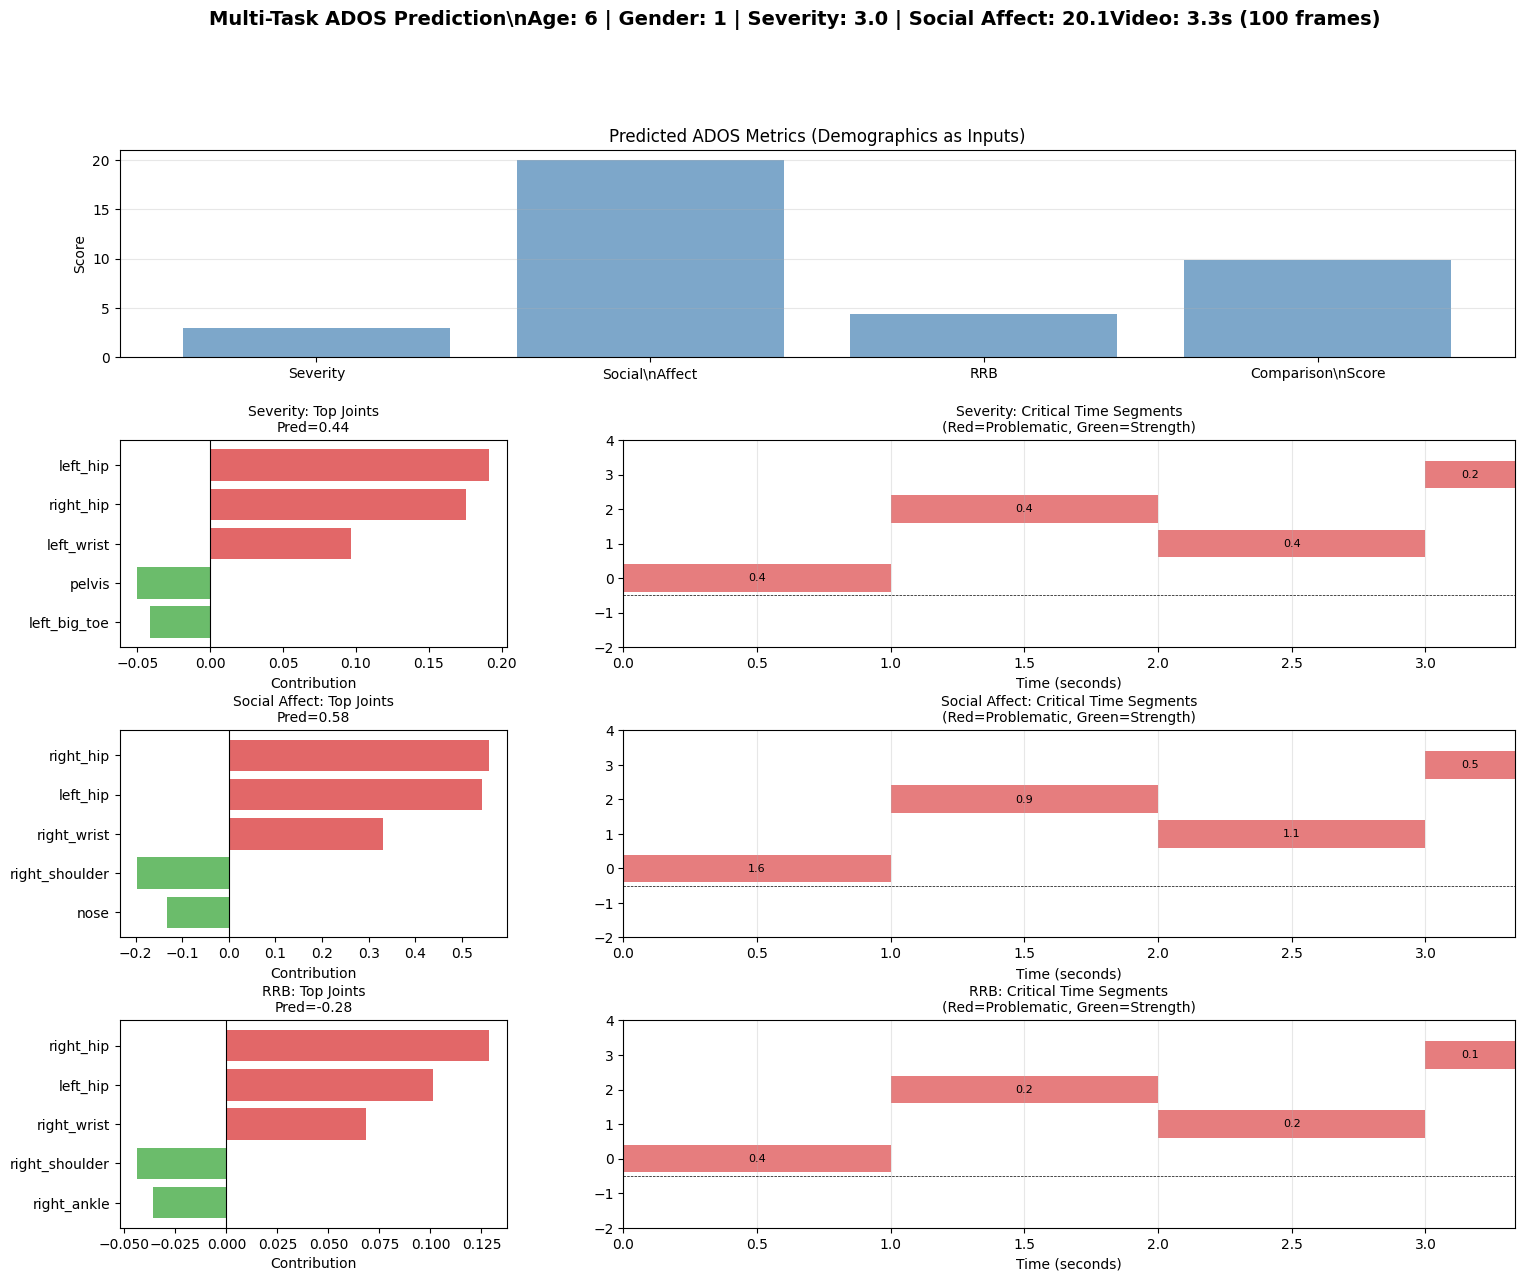


SAMPLE 3/3
Age: 9.7, Gender: 1
Computing explanations for 4 ADOS metrics (Video: 3.3s)...
Computing explanations for 4 ADOS metrics...
  Analyzing Severity...
  Analyzing Social Affect...
  Analyzing RRB...
  Analyzing Comparison Score...
Multi-Task ADOS Assessment (Using Age & Gender as Inputs):\n\nPREDICTIONS:\n  Severity: 2.9\n  Social Affect: 19.2\n  RRB: 5.0\n  Comparison Score: 9.5\n\nINPUT DEMOGRAPHICS:\n  Age: 9.7 years\n  Gender: 1\n\nSeverity: Top joint=left_hip (+1.31), Demographic impact=0.21\nSocial Affect: Top joint=right_hip (+0.39), Demographic impact=0.11\nRRB: Top joint=left_hip (+0.18), Demographic impact=0.07\nComparison Score: Top joint=left_hip (+1.00), Demographic impact=0.19\n

Ground Truth vs Predictions:
  severity: True=2.00, Pred=2.95, Error=0.95
  social_affect: True=9.00, Pred=19.24, Error=10.24
  rrb: True=2.00, Pred=5.02, Error=3.02
  comparison_score: True=7.00, Pred=9.47, Error=2.47

TEMPORAL INSIGHTS (Critical Time Segments):

Severity:
  Problematic

/tmp/ipykernel_47/1931286351.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Visualization saved to multitask_explanation_3.png


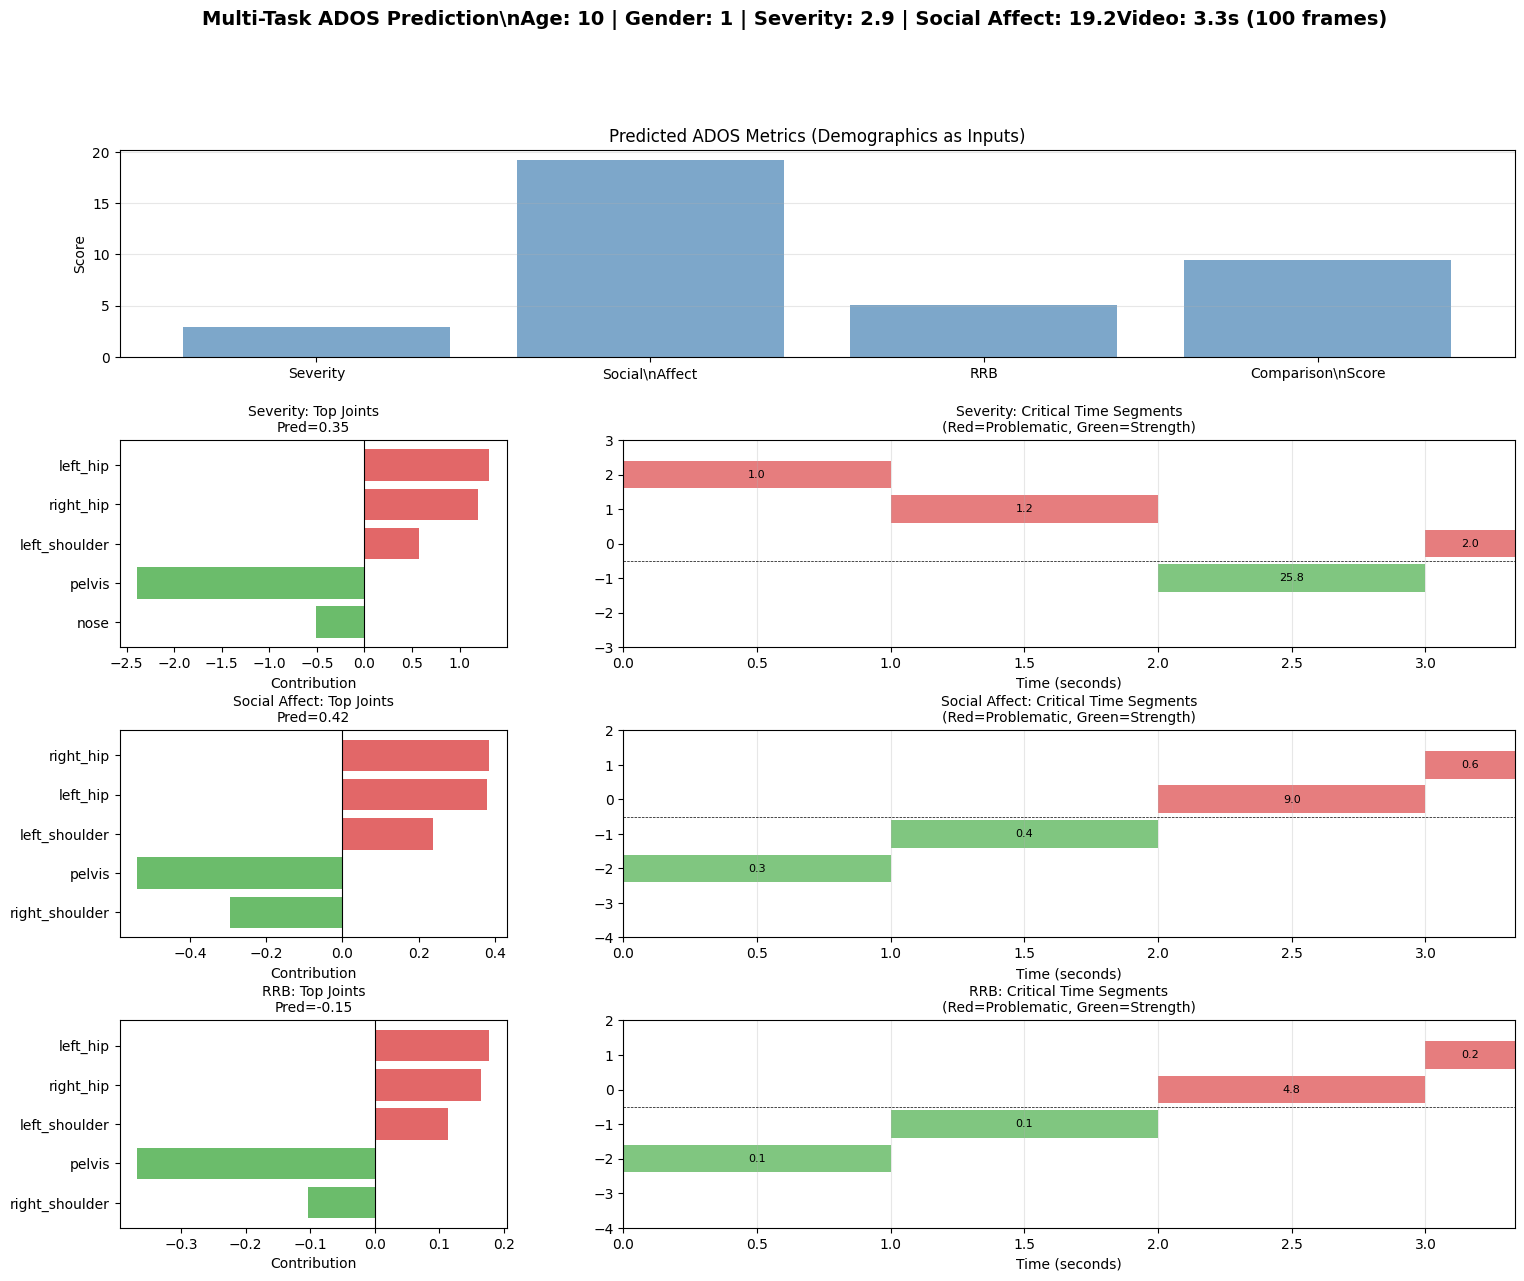


✅ Saved therapy engine input to multitask_therapy_input.json

MULTI-TASK EXPLAINABILITY COMPLETE!

✅ Generated 3 complete explanations
✅ Each explanation shows:
   - Predictions for 4 ADOS metrics
   - How age and gender influence each prediction
   - Which body joints contribute most to each score
   - Temporal patterns and behavioral indicators


In [29]:
# ========================
# 9. Run Multi-Task Explainability (4 ADOS Metrics)
# ========================
def explain_multitask_samples(model, val_loader, target_scalers, fps, demographic_scaler, 
                               num_samples=3, device='cpu'):
    """Generate explanations for multi-task model with demographic inputs"""
    explainer = MultiTaskADOSExplainer(
    model=model,
    target_scalers=target_scalers,
    demographic_scaler=demographic_scaler,
    fps=fps,  # Now correctly passed as fps (not confused with demographic_scaler)
    device=device
)

    explanations = []
    
    print(f"\n{'='*70}")
    print(f"Generating Explanations for {num_samples} samples...")
    print(f"{'='*70}\n")
    
    sample_count = 0
    for x_seq, x_demo, yb_scaled, yb_orig, lens in val_loader:
        for i in range(x_seq.shape[0]):
            if sample_count >= num_samples:
                break
            
            seq = x_seq[i]
            demo = x_demo[i]
            y_true_orig = yb_orig[i].numpy()
            seq_len = lens[i]
            # Get demographics in original scale
            demo_orig = demographic_scaler.inverse_transform(demo.numpy().reshape(1, -1))[0]
            
            print(f"\n{'='*70}")
            print(f"SAMPLE {sample_count + 1}/{num_samples}")
            print(f"Age: {demo_orig[0]:.1f}, Gender: {int(demo_orig[1])}")
            print(f"{'='*70}")
            
            # Generate explanation
            explanation = explainer.explain_all_tasks(
                x_seq=seq,
                seq_len=seq_len,
                x_demo=demo  # or None if your explainer doesn't need fps
            )

            
            # Add ground truth
            explanation['ground_truth'] = {
                'severity': float(y_true_orig[0]),
                'social_affect': float(y_true_orig[1]),
                'rrb': float(y_true_orig[2]),
                'comparison_score': float(y_true_orig[3])
            }
            
            # Print summary
            print(explanation['summary'])
            
            print("\nGround Truth vs Predictions:")
            for i, task in enumerate(['severity', 'social_affect', 'rrb', 'comparison_score']):
                true_val = explanation['ground_truth'][task]
                pred_val = explanation['predictions'][task]
                error = abs(true_val - pred_val)
                print(f"  {task}: True={true_val:.2f}, Pred={pred_val:.2f}, Error={error:.2f}")

            # Print temporal insights
            print("\n" + "="*80)
            print("TEMPORAL INSIGHTS (Critical Time Segments):")
            print("="*80)
            for task_name in ['Severity', 'Social Affect', 'RRB']:
                task_exp = explanation['task_explanations'][task_name]
                print(f"\n{task_name}:")
                
                print("  Problematic segments (increase score):")
                for seg in task_exp['temporal_segments']['positive_segments'][:3]:
                    print(f"    {seg['start_time']:.1f}-{seg['end_time']:.1f}s: contribution={seg['contribution']:.2f}")
                
                print("  Strength segments (decrease score):")
                for seg in task_exp['temporal_segments']['negative_segments'][:2]:
                    print(f"    {seg['start_time']:.1f}-{seg['end_time']:.1f}s: contribution={seg['contribution']:.2f}")
            
            explanations.append(explanation)
            
            # Visualize
            explainer.visualize_explanation(
                explanation, 
                save_path=f'multitask_explanation_{sample_count+1}.png'
            )
            
            sample_count += 1
        
        if sample_count >= num_samples:
            break
    
    # Save for therapy engine
    if explanations:
        with open('multitask_therapy_input.json', 'w') as f:
            json.dump(explanations[0], f, indent=2, default=str)
        print(f"\n✅ Saved therapy engine input to multitask_therapy_input.json")
    
    return explanations

# Run the explainer
explanations = explain_multitask_samples(
    model=model,
    val_loader=val_loader,
    target_scalers=target_scalers,
    fps=30,
    demographic_scaler=demographic_scaler,
    num_samples=3,
    device='cpu'
)

print("\n" + "="*70)
print("MULTI-TASK EXPLAINABILITY COMPLETE!")
print("="*70)
print(f"\n✅ Generated {len(explanations)} complete explanations")
print("✅ Each explanation shows:")
print("   - Predictions for 4 ADOS metrics")
print("   - How age and gender influence each prediction")
print("   - Which body joints contribute most to each score")
print("   - Temporal patterns and behavioral indicators")

In [30]:
# ========================
# 10. Helper Functions for Inference (with Demographic Inputs)
# ========================

def predict_single_sample(model, sequence_folder_path, age, gender_value, 
                          feature_scaler, demographic_scaler, target_scalers, 
                          gender_encoder, max_len=100):
    """
    Make prediction on a single video sequence with demographic information
    
    Args:
        model: Trained multi-task model
        sequence_folder_path: Path to folder containing .npz frame files
        age: Patient's age (years)
        gender_value: Patient's gender (original value, e.g., 'M', 'F')
        feature_scaler: Fitted StandardScaler for skeletal features
        demographic_scaler: Fitted StandardScaler for demographics
        target_scalers: List of scalers for targets
        gender_encoder: LabelEncoder for gender
        max_len: Maximum sequence length
    
    Returns:
        Dictionary with all predictions in original scale
    """
    # Load and process sequence
    sequence = load_npz_sequence(sequence_folder_path)
    
    if sequence.shape[0] == 0:
        return {"error": "Empty sequence"}
    
    # Preprocess skeletal features
    original_length = min(sequence.shape[0], max_len)
    sequence = normalize_skeleton(sequence)
    sequence = pad_sequence(sequence, max_len)
    features = compute_enhanced_features(sequence)
    
    # Normalize skeletal features
    features_flat = features.reshape(-1, features.shape[-1])
    features_normalized = feature_scaler.transform(features_flat)
    features_normalized = features_normalized.reshape(features.shape)
    
    # Encode and normalize demographic features
    gender_encoded = gender_encoder.transform([gender_value])[0]
    demo_features = np.array([[age, gender_encoded]])
    demo_normalized = demographic_scaler.transform(demo_features)
    
    # Convert to tensors
    x_seq = torch.tensor(features_normalized, dtype=torch.float32).unsqueeze(0)
    x_demo = torch.tensor(demo_normalized, dtype=torch.float32).squeeze(0)
    seq_len = torch.tensor([original_length], dtype=torch.long)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(x_seq, x_demo, seq_len)
    
    outputs_np = outputs[0].cpu().numpy()
    
    # Convert to original scale
    predictions = {
        'severity': float(target_scalers[0].inverse_transform([[outputs_np[0]]])[0, 0]),
        'social_affect': float(target_scalers[1].inverse_transform([[outputs_np[1]]])[0, 0]),
        'rrb': float(target_scalers[2].inverse_transform([[outputs_np[2]]])[0, 0]),
        'comparison_score': float(target_scalers[3].inverse_transform([[outputs_np[3]]])[0, 0]),
        'input_age': age,
        'input_gender': gender_value
    }
    
    return predictions

def batch_predict_and_save(model, root_folder, metadata_file, feature_scaler, 
                           demographic_scaler, target_scalers, gender_encoder, 
                           output_file='predictions.csv'):
    """
    Make predictions on all sequences and save to CSV
    """
    results = []
    
    df = pd.read_excel(metadata_file)
    id_to_info = {row['ID#']: row for idx, row in df.iterrows()}
    
    for action in os.listdir(root_folder):
        action_path = os.path.join(root_folder, action)
        if not os.path.isdir(action_path):
            continue
        
        for trial in os.listdir(action_path):
            trial_path = os.path.join(action_path, trial)
            if not os.path.isdir(trial_path):
                continue
            
            try:
                patient_id = int(trial.split('_')[1])
            except (IndexError, ValueError):
                continue
            
            if patient_id not in id_to_info:
                continue
            
            # Get demographic info
            patient_info = id_to_info[patient_id]
            age = patient_info['Age']
            gender = patient_info['Gender']
            
            # Make prediction
            preds = predict_single_sample(
                model, trial_path, age, gender,
                feature_scaler, demographic_scaler, 
                target_scalers, gender_encoder
            )
            
            if 'error' in preds:
                continue
            
            # Build result
            result = {
                'patient_id': patient_id,
                'action': action,
                'trial': trial,
                'age_input': age,
                'gender_input': gender,
                **{k: v for k, v in preds.items() if k not in ['input_age', 'input_gender']}
            }
            
            # Add ground truth
            result['true_severity'] = patient_info['Severity of Autism']
            result['true_social_affect'] = patient_info['Social Affect Total']
            result['true_rrb'] = patient_info['Restricted and Repetitive Behavior Total']
            result['true_comparison'] = patient_info['ADOS Comparison Score']
            
            results.append(result)
    
    # Save to CSV
    results_df = pd.DataFrame(results)
    results_df.to_csv(output_file, index=False)
    
    print(f"✅ Saved {len(results)} predictions to {output_file}")
    
    return results_df

print("✅ Helper functions for inference ready (with demographic inputs)")
print("\nUsage:")
print("  predict_single_sample(model, path, age, gender, ...) - Predict on one video")
print("  batch_predict_and_save(model, ...) - Predict on entire dataset")
print("\nExample:")
print("  preds = predict_single_sample(model, 'path/to/video', age=8, gender_value='M', ...)")
print("  # Returns: {'severity': 12.3, 'social_affect': 8.5, 'rrb': 3.8, 'comparison_score': 7.2}")

✅ Helper functions for inference ready (with demographic inputs)

Usage:
  predict_single_sample(model, path, age, gender, ...) - Predict on one video
  batch_predict_and_save(model, ...) - Predict on entire dataset

Example:
  preds = predict_single_sample(model, 'path/to/video', age=8, gender_value='M', ...)
  # Returns: {'severity': 12.3, 'social_affect': 8.5, 'rrb': 3.8, 'comparison_score': 7.2}


In [ ]:
with open('multitask_therapy_input.json', 'r') as f:
        print(f.read())

# 3D Model

In [ ]:
# ========================
# 3D Model - Step 1: Enhanced preprocessing for 3D coordinates
# ========================
import numpy as np
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

def load_npz_sequence_3d(folder_path):
    """Load 3D skeleton sequence (24 joints with x, y, z coordinates)"""
    frame_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    sequence = []
    for f in frame_files:
        data = np.load(os.path.join(folder_path, f))['coordinates']
        if data.shape[0] > 0:
            person_data = data[0]  # Take first person
            sequence.append(person_data)
    if not sequence:
        return np.empty((0, 24, 3))  # 3D coordinates
    return np.array(sequence)

def normalize_skeleton_3d(sequence):
    """Improved normalization for 3D skeleton with stability"""
    if sequence.shape[0] == 0:
        return sequence
    
    # Center around hip midpoint (3D)
    center = (sequence[:, 8:9, :] + sequence[:, 11:12, :]) / 2
    sequence = sequence - center
    
    # Normalize by torso length for scale invariance (3D distance)
    torso_length = np.linalg.norm(
        sequence[:, 1, :] - (sequence[:, 8, :] + sequence[:, 11, :]) / 2,
        axis=1, keepdims=True
    )
    torso_length = np.maximum(torso_length, 1e-6)  # Avoid division by zero
    sequence = sequence / (torso_length[:, :, np.newaxis] + 1e-6)
    
    return sequence

def pad_sequence_3d(seq, max_len=100):
    """Pad 3D sequence to fixed length"""
    num_frames, num_joints, _ = seq.shape
    if num_frames >= max_len:
        return seq[:max_len]
    else:
        pad_len = max_len - num_frames
        padding = np.zeros((pad_len, num_joints, 3))  # 3D padding
        return np.concatenate([seq, padding], axis=0)

def compute_enhanced_features_3d(sequence):
    """
    Enhanced feature extraction for 3D skeleton data
    Same behavioral signals as 2D but with 3D coordinates
    """
    num_frames = sequence.shape[0]
    
    # 1. Flattened joint positions (72 features: 24 joints * 3 coords)
    flat_joints = sequence.reshape(num_frames, -1)
    
    # 2. Velocity (72 features)
    velocity = np.zeros_like(flat_joints)
    velocity[1:] = flat_joints[1:] - flat_joints[:-1]
    
    # 3. Acceleration (72 features)
    acceleration = np.zeros_like(flat_joints)
    acceleration[1:] = velocity[1:] - velocity[:-1]
    
    # 4. Key joint distances (behavioral indicators) - 3D distances
    # Hand-hand distance
    left_wrist = sequence[:, 7, :]
    right_wrist = sequence[:, 4, :]
    dist_hands = np.linalg.norm(left_wrist - right_wrist, axis=1, keepdims=True)
    
    # Elbow-elbow distance
    left_elbow = sequence[:, 6, :]
    right_elbow = sequence[:, 3, :]
    dist_elbows = np.linalg.norm(left_elbow - right_elbow, axis=1, keepdims=True)
    
    # Hand-to-body distances (self-stimulatory behaviors)
    neck = sequence[:, 1, :]
    dist_left_hand_body = np.linalg.norm(left_wrist - neck, axis=1, keepdims=True)
    dist_right_hand_body = np.linalg.norm(right_wrist - neck, axis=1, keepdims=True)
    
    # 5. Movement magnitude (overall activity level)
    movement_mag = np.linalg.norm(velocity.reshape(num_frames, -1), axis=1, keepdims=True)
    
    # 6. Symmetry features (left-right coordination)
    left_shoulder = sequence[:, 5, :]
    right_shoulder = sequence[:, 2, :]
    shoulder_symmetry = np.linalg.norm(
        (left_wrist - left_shoulder) - (right_wrist - right_shoulder),
        axis=1, keepdims=True
    )
    
    # Combine all features (72 + 72 + 72 + 1 + 1 + 1 + 1 + 1 + 1 = 222 features)
    features = np.concatenate([
        flat_joints,           # 72
        velocity,              # 72
        acceleration,          # 72
        dist_hands,            # 1
        dist_elbows,           # 1
        dist_left_hand_body,   # 1
        dist_right_hand_body,  # 1
        movement_mag,          # 1
        shoulder_symmetry      # 1
    ], axis=1)
    
    return features

print("✅ 3D preprocessing functions ready")
print("Key differences from 2D:")
print("  - Input: 24 joints × 3 coordinates (x, y, z)")
print("  - Features: 222 per frame (vs 150 in 2D)")
print("  - Distance calculations use 3D Euclidean norm")

In [ ]:
# ========================
# 3D Model - Step 2: Load 3D dataset with demographics
# ========================
root_folder_3d = "/kaggle/input/3d-coords/ROMP_3D_Coordinates"
metadata_file = "/kaggle/input/ados-rating/ADOS_rating.xlsx"
max_len = 100

def convert_age_to_years(age_str):
    """
    Convert age from format like "5Y,10M" to decimal years
    Example: "5Y,10M" -> 5 + 10/12 = 5.833
             "8Y,0M" -> 8.0
             "3Y,6M" -> 3.5
    """
    try:
        # If already a number, return it
        if isinstance(age_str, (int, float)):
            return float(age_str)
        
        # Convert to string and clean
        age_str = str(age_str).strip()
        
        # Split by comma
        parts = age_str.split(',')
        
        years = 0
        months = 0
        
        for part in parts:
            part = part.strip().upper()
            if 'Y' in part:
                years = int(part.replace('Y', '').strip())
            elif 'M' in part:
                months = int(part.replace('M', '').strip())
        
        # Convert to decimal years
        decimal_age = years + (months / 12.0)
        return decimal_age
    
    except Exception as e:
        print(f"Warning: Could not convert age '{age_str}': {e}")
        return None

# Reuse the age conversion function from 2D model
# Load metadata (same as 2D)
df = pd.read_excel(metadata_file)

print("Available columns in ADOS rating file:")
print(df.columns.tolist())
print(f"\nDataset has {len(df)} patients")

# Same target columns as 2D model
target_columns = {
    'severity': 'Severity of Autism  ',
    'age': 'Chronological Age',
    'gender': 'Gender',
    'social_affect': 'Social Affect Total ',
    'rrb': 'Restricted and Repetitive Behavior (RRB) Total',
    'comparison_score': 'ADOS Comparison Score (1-10) <5  not very autistic. ASD people usually fall 5-10. 8-10=Severe, 5-7=moderate, 1-4=mild',
    'overall_total': 'Overall Total '
}

# Create mappings (same as 2D)
id_to_data_3d = {}
for idx, row in df.iterrows():
    patient_id = row['ID#']
    age_value = convert_age_to_years(row[target_columns['age']])
    if age_value is None:
        continue
    id_to_data_3d[patient_id] = {
        'severity': row[target_columns['severity']],
        'age': age_value,
        'gender': row[target_columns['gender']],
        'social_affect': row[target_columns['social_affect']],
        'rrb': row[target_columns['rrb']],
        'comparison_score': row[target_columns['comparison_score']],
        'overall_total': row[target_columns['overall_total']]
    }

# Encode gender (same encoder as 2D for consistency)
gender_encoder_3d = LabelEncoder()
all_genders_3d = [data['gender'] for data in id_to_data_3d.values() if pd.notna(data['gender'])]
gender_encoder_3d.fit(all_genders_3d)
print(f"\nGender encoding: {dict(zip(gender_encoder_3d.classes_, gender_encoder_3d.transform(gender_encoder_3d.classes_)))}")

# Load 3D sequences and labels
sequence_features_3d = []
demographic_features_3d = []
labels_3d = []
sequence_lengths_3d = []
valid_patient_ids_3d = []

print(f"\nLoading 3D sequences from: {root_folder_3d}")

for action in os.listdir(root_folder_3d):
    action_path = os.path.join(root_folder_3d, action)
    if not os.path.isdir(action_path):
        continue
    for trial in os.listdir(action_path):
        trial_path = os.path.join(action_path, trial)
        if not os.path.isdir(trial_path):
            continue
        try:
            patient_id = int(trial.split('_')[1])
        except (IndexError, ValueError):
            continue
        if patient_id not in id_to_data_3d:
            continue
        
        # Load 3D sequence
        sequence = load_npz_sequence_3d(trial_path)
        if sequence.shape[0] == 0:
            continue
        
        patient_data = id_to_data_3d[patient_id]
        
        # Check for missing values
        if any(pd.isna(patient_data[k]) for k in patient_data.keys()):
            continue
        
        # Encode demographics
        gender_encoded = gender_encoder_3d.transform([patient_data['gender']])[0]
        age_value = patient_data['age']
        
        # Process 3D sequence
        original_length = min(sequence.shape[0], max_len)
        sequence = normalize_skeleton_3d(sequence)
        sequence = pad_sequence_3d(sequence, max_len)
        features = compute_enhanced_features_3d(sequence)
        
        # Store features
        sequence_features_3d.append(features)
        demographic_features_3d.append([age_value, gender_encoded])
        
        # Create label vector (same 4 targets as 2D)
        label_vector = [
            patient_data['severity'],
            patient_data['social_affect'],
            patient_data['rrb'],
            patient_data['comparison_score']
        ]
        labels_3d.append(label_vector)
        sequence_lengths_3d.append(original_length)
        valid_patient_ids_3d.append(patient_id)

sequence_features_3d = np.array(sequence_features_3d)
demographic_features_3d = np.array(demographic_features_3d)
labels_3d = np.array(labels_3d)
sequence_lengths_3d = np.array(sequence_lengths_3d)

print(f"\n3D Sequence features shape: {sequence_features_3d.shape}")
print(f"3D Demographic features shape: {demographic_features_3d.shape}")
print(f"3D Labels shape: {labels_3d.shape}")
print(f"Number of 3D samples: {len(sequence_features_3d)}")

# Print statistics
print("\n" + "="*70)
print("3D MODEL - INPUT FEATURES (Demographics)")
print("="*70)
print(f"Age            - Mean: {demographic_features_3d[:, 0].mean():6.2f}, Std: {demographic_features_3d[:, 0].std():6.2f}")
print(f"Gender (0/1)   - Mean: {demographic_features_3d[:, 1].mean():6.2f}, Distribution: {np.bincount(demographic_features_3d[:, 1].astype(int))}")

print("\n" + "="*70)
print("3D MODEL - TARGET VARIABLES (ADOS Metrics)")
print("="*70)
target_names_3d = ['Severity', 'Social Affect', 'RRB', 'Comparison Score']
for i, name in enumerate(target_names_3d):
    print(f"{name:20s} - Mean: {labels_3d[:, i].mean():6.2f}, Std: {labels_3d[:, i].std():6.2f}, Min: {labels_3d[:, i].min():6.2f}, Max: {labels_3d[:, i].max():6.2f}")
print("="*70)

In [ ]:
# Clean labels for 3D data (same process as 2D)
labels_3d = np.array(labels_3d, dtype=object).astype(str)

clean_labels_3d = []
for row in labels_3d:
    clean_row = []
    for value in row:
        try:
            clean_value = float(value)
        except:
            clean_value = None
        clean_row.append(clean_value)
    clean_labels_3d.append(clean_row)

clean_labels_3d = np.array(clean_labels_3d, dtype=object)

# Remove rows with None
valid_mask_3d = ~np.any(pd.isna(clean_labels_3d).astype(bool), axis=1)
clean_labels_3d = clean_labels_3d[valid_mask_3d]
sequence_features_3d = sequence_features_3d[valid_mask_3d]
demographic_features_3d = demographic_features_3d[valid_mask_3d]
sequence_lengths_3d = sequence_lengths_3d[valid_mask_3d]

# Convert to float
labels_3d = clean_labels_3d.astype(float)
labels_3d = np.array(labels_3d)

print(f"✅ Cleaned 3D labels: {labels_3d.shape}")
print(f"✅ Final 3D samples: {len(sequence_features_3d)}")

In [ ]:
# ========================
# 3D Model - Step 3: Feature normalization and target scaling
# ========================
# Normalize 3D skeletal features
original_shape_3d = sequence_features_3d.shape
sequence_reshaped_3d = sequence_features_3d.reshape(-1, sequence_features_3d.shape[-1])

feature_scaler_3d = StandardScaler()
sequence_normalized_3d = feature_scaler_3d.fit_transform(sequence_reshaped_3d)
sequence_features_3d = sequence_normalized_3d.reshape(original_shape_3d)

# Normalize demographic features
demographic_scaler_3d = StandardScaler()
demographic_features_normalized_3d = demographic_scaler_3d.fit_transform(demographic_features_3d)

print("3D Feature scaling:")
print(f"  Skeletal features (222 per frame): StandardScaler applied")
print(f"  Age: StandardScaler applied (as input feature)")
print(f"  Gender: StandardScaler applied (as input feature)")

# Scale targets (same 4 regression tasks)
target_scalers_3d = []
labels_scaled_3d = np.zeros_like(labels_3d)

for i in range(labels_3d.shape[1]):
    scaler = StandardScaler()
    labels_scaled_3d[:, i] = scaler.fit_transform(labels_3d[:, i].reshape(-1, 1)).flatten()
    target_scalers_3d.append(scaler)

print("\n3D Target scaling applied:")
print(f"  Severity: Scaled")
print(f"  Social Affect: Scaled")
print(f"  RRB: Scaled")
print(f"  Comparison Score: Scaled")

# Convert to torch tensors
X_sequence_3d = torch.tensor(sequence_features_3d, dtype=torch.float32)
X_demographic_3d = torch.tensor(demographic_features_normalized_3d, dtype=torch.float32)
y_3d = torch.tensor(labels_scaled_3d, dtype=torch.float32)
seq_lens_3d = torch.tensor(sequence_lengths_3d, dtype=torch.long)

# Store original labels for evaluation
y_original_3d = torch.tensor(labels_3d, dtype=torch.float32)

# Train/validation split (same ratio as 2D)
dataset_3d = TensorDataset(X_sequence_3d, X_demographic_3d, y_3d, y_original_3d, seq_lens_3d)
train_size_3d = int(0.8 * len(dataset_3d))
val_size_3d = len(dataset_3d) - train_size_3d

train_dataset_3d, val_dataset_3d = torch.utils.data.random_split(
    dataset_3d, [train_size_3d, val_size_3d],
    generator=torch.Generator().manual_seed(42)
)

train_loader_3d = DataLoader(train_dataset_3d, batch_size=32, shuffle=True)
val_loader_3d = DataLoader(val_dataset_3d, batch_size=32, shuffle=False)

print(f"\n3D Dataset split:")
print(f"  Training samples: {train_size_3d}")
print(f"  Validation samples: {val_size_3d}")
print(f"  Batch size: 32")

In [ ]:
# ========================
# 3D Model - Step 4: Multi-Task ADOS Model (SAME ARCHITECTURE as 2D)
# ========================
# Note: We reuse the ImprovedADOSModel class defined earlier, just instantiate it with 3D input size

sequence_input_size_3d = sequence_features_3d.shape[2]  # 222 features for 3D
demographic_input_size_3d = demographic_features_3d.shape[1]  # 2 (age, gender)

model_3d = ImprovedADOSModel(
    sequence_input_size=sequence_input_size_3d,
    demographic_input_size=demographic_input_size_3d,
    hidden_size=128,
    num_layers=2,
    dropout=0.4,
    num_outputs=4
)

print("3D Multi-Task Model Architecture:")
print(f"  Input: Sequence features ({sequence_input_size_3d} per frame) + Demographic features (age, gender)")
print("  Shared: Bidirectional LSTM + Attention + Demographic FC + Combined FC")
print("  Task-specific heads (all regression):")
print("    - Severity")
print("    - Social Affect")
print("    - RRB")
print("    - Comparison Score")
print("\n✅ Same architecture as 2D model, only input dimension changed (222 vs 150)")
print(f"Total parameters: {sum(p.numel() for p in model_3d.parameters()):,}")

In [ ]:
# ========================
# 3D Model - Step 5: Multi-Task Training (Same Loss Function)
# ========================

# Multi-task loss function (4 regression tasks)
def multi_task_loss(predictions, targets, task_weights=None):
    """
    Compute weighted multi-task loss for 4 ADOS metrics
    predictions: [batch, 4]
    targets: [batch, 4]
    
    Task breakdown:
    - 0: Severity (Huber Loss)
    - 1: Social Affect (Huber Loss)
    - 2: RRB (Huber Loss)
    - 3: Comparison Score (Huber Loss)
    """
    if task_weights is None:
        # Default weights (can be tuned based on importance)
        task_weights = {
            'severity': 1.5,
            'social_affect': 1.3,
            'rrb': 1.3,
            'comparison': 1.0
        }
    
    # Huber loss for robustness to outliers
    huber = nn.HuberLoss(delta=1.0)
    
    loss_severity = huber(predictions[:, 0], targets[:, 0])
    loss_social_affect = huber(predictions[:, 1], targets[:, 1])
    loss_rrb = huber(predictions[:, 2], targets[:, 2])
    loss_comparison = huber(predictions[:, 3], targets[:, 3])
    
    # Weighted total loss
    total_loss = (
        task_weights['severity'] * loss_severity +
        task_weights['social_affect'] * loss_social_affect +
        task_weights['rrb'] * loss_rrb +
        task_weights['comparison'] * loss_comparison
    )
    
    # Return total loss and individual losses for monitoring
    losses_dict = {
        'total': total_loss,
        'severity': loss_severity,
        'social_affect': loss_social_affect,
        'rrb': loss_rrb,
        'comparison': loss_comparison
    }
    
    return total_loss, losses_dict
# Optimizer with weight decay
optimizer_3d = torch.optim.AdamW(model_3d.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler
scheduler_3d = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_3d, mode='min', factor=0.5, patience=5, verbose=True
)

# Early stopping
best_val_loss_3d = float('inf')
patience_3d = 15
patience_counter_3d = 0

num_epochs_3d = 100

print("\n" + "="*70)
print("STARTING 3D MULTI-TASK TRAINING (4 ADOS METRICS)")
print("="*70)
print(f"Epochs: {num_epochs_3d}")
print(f"Learning rate: 1e-3")
print(f"Early stopping patience: {patience_3d}")
print(f"Using Age and Gender as INPUT features")
print("="*70 + "\n")

for epoch in range(num_epochs_3d):
    # Training
    model_3d.train()
    train_loss_3d = 0
    train_losses_sum_3d = {k: 0.0 for k in ['severity', 'social_affect', 'rrb', 'comparison']}
    
    for x_seq, x_demo, yb, yb_orig, lens in train_loader_3d:
        optimizer_3d.zero_grad()
        out = model_3d(x_seq, x_demo, lens)
        loss, losses_dict = multi_task_loss(out, yb)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model_3d.parameters(), max_norm=1.0)
        
        optimizer_3d.step()
        
        train_loss_3d += loss.item() * x_seq.size(0)
        for k in train_losses_sum_3d.keys():
            train_losses_sum_3d[k] += losses_dict[k].item() * x_seq.size(0)
    
    train_loss_3d /= len(train_loader_3d.dataset)
    for k in train_losses_sum_3d.keys():
        train_losses_sum_3d[k] /= len(train_loader_3d.dataset)
    
    # Validation
    model_3d.eval()
    val_loss_3d = 0
    val_losses_sum_3d = {k: 0.0 for k in ['severity', 'social_affect', 'rrb', 'comparison']}
    
    with torch.no_grad():
        for x_seq, x_demo, yb, yb_orig, lens in val_loader_3d:
            out = model_3d(x_seq, x_demo, lens)
            loss, losses_dict = multi_task_loss(out, yb)
            
            val_loss_3d += loss.item() * x_seq.size(0)
            for k in val_losses_sum_3d.keys():
                val_losses_sum_3d[k] += losses_dict[k].item() * x_seq.size(0)
    
    val_loss_3d /= len(val_loader_3d.dataset)
    for k in val_losses_sum_3d.keys():
        val_losses_sum_3d[k] /= len(val_loader_3d.dataset)
    
    # Learning rate scheduling
    scheduler_3d.step(val_loss_3d)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs_3d}")
        print(f"  Train Loss: {train_loss_3d:.4f} | Val Loss: {val_loss_3d:.4f}")
        print(f"  Task Losses (Val):")
        print(f"    Severity: {val_losses_sum_3d['severity']:.4f}")
        print(f"    Social Affect: {val_losses_sum_3d['social_affect']:.4f}")
        print(f"    RRB: {val_losses_sum_3d['rrb']:.4f}")
        print(f"    Comparison: {val_losses_sum_3d['comparison']:.4f}")
    
    # Early stopping
    if val_loss_3d < best_val_loss_3d:
        best_val_loss_3d = val_loss_3d
        patience_counter_3d = 0
        torch.save(model_3d.state_dict(), 'best_ados_multitask_model_3d.pth')
    else:
        patience_counter_3d += 1
        if patience_counter_3d >= patience_3d:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
model_3d.load_state_dict(torch.load('best_ados_multitask_model_3d.pth'))
print("\n✅ Best 3D model loaded")

In [ ]:
# ========================
# 3D Model - Step 6: Comprehensive Evaluation Metrics
# ========================
model_3d.eval()

# Collect predictions and targets
all_preds_3d = []
all_targets_scaled_3d = []
all_targets_original_3d = []
all_demographics_3d = []

with torch.no_grad():
    for x_seq, x_demo, yb_scaled, yb_orig, lens in val_loader_3d:
        out = model_3d(x_seq, x_demo, lens)
        all_preds_3d.append(out.numpy())
        all_targets_scaled_3d.append(yb_scaled.numpy())
        all_targets_original_3d.append(yb_orig.numpy())
        all_demographics_3d.append(x_demo.numpy())

# Concatenate all batches
preds_scaled_3d = np.concatenate(all_preds_3d, axis=0)
targets_scaled_3d = np.concatenate(all_targets_scaled_3d, axis=0)
targets_original_3d = np.concatenate(all_targets_original_3d, axis=0)
demographics_scaled_3d = np.concatenate(all_demographics_3d, axis=0)

# Convert predictions back to original scale
preds_original_3d = np.zeros((preds_scaled_3d.shape[0], 4))

for i in range(4):
    preds_original_3d[:, i] = target_scalers_3d[i].inverse_transform(preds_scaled_3d[:, i].reshape(-1, 1)).flatten()

# Inverse transform demographics
demographics_original_3d = demographic_scaler_3d.inverse_transform(demographics_scaled_3d)

# Calculate metrics for each task
target_names_3d = ['Severity', 'Social Affect', 'RRB', 'Comparison Score']

print("\n" + "="*80)
print("3D MODEL - FINAL VALIDATION METRICS")
print("="*80)
print("Using Age and Gender as INPUT features (not predicted)")
print("="*80)

for i, name in enumerate(target_names_3d):
    y_true = targets_original_3d[:, i]
    y_pred = preds_original_3d[:, i]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Calculate relative error
    mean_true = np.mean(y_true)
    relative_mae = (mae / mean_true) * 100 if mean_true != 0 else float('inf')
    
    print(f"\n{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  Relative MAE: {relative_mae:.2f}%")
    print(f"  Mean True Value: {mean_true:.2f}")

print("\n" + "="*80)

# Overall summary
print("\n3D MODEL - OVERALL PERFORMANCE SUMMARY:")
print("-" * 80)

avg_r2_3d = np.mean([r2_score(targets_original_3d[:, i], preds_original_3d[:, i]) for i in range(4)])
avg_mae_percent_3d = np.mean([
    (mean_absolute_error(targets_original_3d[:, i], preds_original_3d[:, i]) / np.mean(targets_original_3d[:, i])) * 100
    for i in range(4) if np.mean(targets_original_3d[:, i]) != 0
])

print(f"  Average R² (all tasks): {avg_r2_3d:.4f}")
print(f"  Average Relative MAE: {avg_mae_percent_3d:.2f}%")

print("\n" + "="*80)
print("DEMOGRAPHIC FEATURES (used as input):")
print(f"  Age - Mean: {demographics_original_3d[:, 0].mean():.2f}, Std: {demographics_original_3d[:, 0].std():.2f}")
print(f"  Gender - Distribution: {np.bincount(demographics_original_3d[:, 1].astype(int))}")
print("="*80)

# Save predictions
results_df_3d = pd.DataFrame({
    'Severity_True': targets_original_3d[:, 0],
    'Severity_Pred': preds_original_3d[:, 0],
    'SocialAffect_True': targets_original_3d[:, 1],
    'SocialAffect_Pred': preds_original_3d[:, 1],
    'RRB_True': targets_original_3d[:, 2],
    'RRB_Pred': preds_original_3d[:, 2],
    'ComparisonScore_True': targets_original_3d[:, 3],
    'ComparisonScore_Pred': preds_original_3d[:, 3],
    'Age_Input': demographics_original_3d[:, 0],
    'Gender_Input': demographics_original_3d[:, 1]
})

results_df_3d.to_csv('multitask_predictions_3d.csv', index=False)
print("\n✅ 3D predictions saved to 'multitask_predictions_3d.csv'")

In [ ]:
# ========================
# 3D Model - Step 7: Visualization of Results
# ========================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('3D Multi-Task ADOS Prediction Results (Age & Gender as Inputs)', fontsize=16, fontweight='bold')

task_names_plot_3d = ['Severity', 'Social Affect', 'RRB', 'Comparison Score']

for idx, task_name in enumerate(task_names_plot_3d):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    y_true = targets_original_3d[:, idx]
    y_pred = preds_original_3d[:, idx]
    
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.6, s=50, color='green')
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    ax.set_xlabel('True Values', fontsize=11)
    ax.set_ylabel('Predicted Values', fontsize=11)
    ax.set_title(f'{task_name} (3D)\nMAE: {mae:.3f}, R²: {r2:.3f}', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multitask_results_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 3D visualization saved to 'multitask_results_3d.png'")

In [ ]:
# ========================
# 3D Model - Step 8: Multi-Task Explainability (Same as 2D)
# ========================
# The explainer can be reused with the 3D model

def explain_multitask_samples_3d(model, val_loader, target_scalers, demographic_scaler, 
                                  fps=30, num_samples=3, device='cpu'):
    """Generate explanations for 3D multi-task model"""
    explainer = MultiTaskADOSExplainer(
        model=model,
        target_scalers=target_scalers,
        demographic_scaler=demographic_scaler,
        fps=fps,
        device=device
    )
    
    explanations = []
    
    print(f"\n{'='*70}")
    print(f"Generating 3D Explanations for {num_samples} samples...")
    print(f"{'='*70}\n")
    
    sample_count = 0
    for x_seq, x_demo, yb_scaled, yb_orig, lens in val_loader:
        for i in range(x_seq.shape[0]):
            if sample_count >= num_samples:
                break
            
            seq = x_seq[i]
            demo = x_demo[i]
            y_true_orig = yb_orig[i].numpy()
            seq_len = lens[i]
            
            # Get demographics in original scale
            demo_orig = demographic_scaler.inverse_transform(demo.numpy().reshape(1, -1))[0]
            
            print(f"\n{'='*70}")
            print(f"3D SAMPLE {sample_count + 1}/{num_samples}")
            print(f"Age: {demo_orig[0]:.1f}, Gender: {int(demo_orig[1])}")
            print(f"{'='*70}")
            
            # Generate explanation
            explanation = explainer.explain_all_tasks(
                x_seq=seq,
                x_demo=demo,
                seq_len=seq_len
            )
            
            # Add ground truth
            explanation['ground_truth'] = {
                'severity': float(y_true_orig[0]),
                'social_affect': float(y_true_orig[1]),
                'rrb': float(y_true_orig[2]),
                'comparison_score': float(y_true_orig[3])
            }
            
            # Print summary
            print(explanation['summary'])
            
            print("\nGround Truth vs Predictions:")
            for j, task in enumerate(['severity', 'social_affect', 'rrb', 'comparison_score']):
                true_val = explanation['ground_truth'][task]
                pred_val = explanation['predictions'][task]
                error = abs(true_val - pred_val)
                print(f"  {task}: True={true_val:.2f}, Pred={pred_val:.2f}, Error={error:.2f}")
            
            # Print temporal insights
            print("\n" + "="*80)
            print("3D TEMPORAL INSIGHTS (Critical Time Segments):")
            print("="*80)
            for task_name in ['Severity', 'Social Affect', 'RRB']:
                task_exp = explanation['task_explanations'][task_name]
                print(f"\n{task_name}:")
                
                print("  Problematic segments (increase score):")
                for seg in task_exp['temporal_segments']['positive_segments'][:3]:
                    print(f"    {seg['start_time']:.1f}-{seg['end_time']:.1f}s: contribution={seg['contribution']:.2f}")
                
                print("  Strength segments (decrease score):")
                for seg in task_exp['temporal_segments']['negative_segments'][:2]:
                    print(f"    {seg['start_time']:.1f}-{seg['end_time']:.1f}s: contribution={seg['contribution']:.2f}")
            
            explanations.append(explanation)
            
            # Visualize
            explainer.visualize_explanation(
                explanation, 
                save_path=f'multitask_explanation_3d_{sample_count+1}.png'
            )
            
            sample_count += 1
        
        if sample_count >= num_samples:
            break
    
    # Save for therapy engine
    if explanations:
        with open('multitask_therapy_input_3d.json', 'w') as f:
            json.dump(explanations[0], f, indent=2, default=str)
        print(f"\n✅ Saved 3D therapy engine input to multitask_therapy_input_3d.json")
    
    return explanations

# Run the 3D explainer
explanations_3d = explain_multitask_samples_3d(
    model=model_3d,
    val_loader=val_loader_3d,
    target_scalers=target_scalers_3d,
    demographic_scaler=demographic_scaler_3d,
    fps=30,
    num_samples=3,
    device='cpu'
)

print("\n" + "="*70)
print("3D MULTI-TASK EXPLAINABILITY COMPLETE!")
print("="*70)
print(f"\n✅ Generated {len(explanations_3d)} complete 3D explanations")
print("✅ Each explanation shows:")
print("   - Predictions for 4 ADOS metrics from 3D skeleton data")
print("   - How age and gender influence each prediction")
print("   - Which body joints contribute most to each score")
print("   - Temporal patterns and behavioral indicators")

In [ ]:
# ========================
# 3D Model - Step 9: Helper Functions for Inference
# ========================
def predict_single_sample_3d(model, sequence_folder_path, age, gender_value, 
                              feature_scaler, demographic_scaler, target_scalers, 
                              gender_encoder, max_len=100):
    """
    Make prediction on a single 3D video sequence with demographic information
    
    Args:
        model: Trained 3D multi-task model
        sequence_folder_path: Path to folder containing .npz frame files (3D)
        age: Patient's age (years)
        gender_value: Patient's gender (original value, e.g., 'M', 'F')
        feature_scaler: Fitted StandardScaler for 3D skeletal features
        demographic_scaler: Fitted StandardScaler for demographics
        target_scalers: List of scalers for targets
        gender_encoder: LabelEncoder for gender
        max_len: Maximum sequence length
    
    Returns:
        Dictionary with all predictions in original scale
    """
    # Load and process 3D sequence
    sequence = load_npz_sequence_3d(sequence_folder_path)
    
    if sequence.shape[0] == 0:
        return {"error": "Empty sequence"}
    
    # Preprocess 3D skeletal features
    original_length = min(sequence.shape[0], max_len)
    sequence = normalize_skeleton_3d(sequence)
    sequence = pad_sequence_3d(sequence, max_len)
    features = compute_enhanced_features_3d(sequence)
    
    # Normalize skeletal features
    features_flat = features.reshape(-1, features.shape[-1])
    features_normalized = feature_scaler.transform(features_flat)
    features_normalized = features_normalized.reshape(features.shape)
    
    # Encode and normalize demographic features
    gender_encoded = gender_encoder.transform([gender_value])[0]
    demo_features = np.array([[age, gender_encoded]])
    demo_normalized = demographic_scaler.transform(demo_features)
    
    # Convert to tensors
    x_seq = torch.tensor(features_normalized, dtype=torch.float32).unsqueeze(0)
    x_demo = torch.tensor(demo_normalized, dtype=torch.float32).squeeze(0)
    seq_len = torch.tensor([original_length], dtype=torch.long)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(x_seq, x_demo, seq_len)
    
    outputs_np = outputs[0].cpu().numpy()
    
    # Convert to original scale
    predictions = {
        'severity': float(target_scalers[0].inverse_transform([[outputs_np[0]]])[0, 0]),
        'social_affect': float(target_scalers[1].inverse_transform([[outputs_np[1]]])[0, 0]),
        'rrb': float(target_scalers[2].inverse_transform([[outputs_np[2]]])[0, 0]),
        'comparison_score': float(target_scalers[3].inverse_transform([[outputs_np[3]]])[0, 0]),
        'input_age': age,
        'input_gender': gender_value
    }
    
    return predictions

print("✅ 3D helper functions for inference ready")
print("\nUsage:")
print("  predict_single_sample_3d(model_3d, path, age, gender, ...) - Predict on one 3D video")
print("\nExample:")
print("  preds = predict_single_sample_3d(model_3d, 'path/to/video', age=8, gender_value='M', ...)")
print("  # Returns: {'severity': 12.3, 'social_affect': 8.5, 'rrb': 3.8, 'comparison_score': 7.2}")


COMPARISON: 2D MODEL vs 3D MODEL

Detailed Comparison:
--------------------------------------------------------------------------------

Severity:
  2D Model - MAE: 0.0628, RMSE: 0.1608, R²: 0.8514
  3D Model - MAE: 0.0648, RMSE: 0.1729, R²: 0.8282
  Improvement - MAE: -3.25%, RMSE: -7.52%, R²: -2.72%

Social Affect:
  2D Model - MAE: 1.6882, RMSE: 2.5105, R²: 0.7969
  3D Model - MAE: 1.4985, RMSE: 2.6082, R²: 0.7808
  Improvement - MAE: +11.24%, RMSE: -3.89%, R²: -2.02%

RRB:
  2D Model - MAE: 0.9390, RMSE: 1.3841, R²: 0.9141
  3D Model - MAE: 0.9268, RMSE: 1.9902, R²: 0.8224
  Improvement - MAE: +1.30%, RMSE: -43.80%, R²: -10.03%

Comparison Score:
  2D Model - MAE: 0.3718, RMSE: 0.6386, R²: 0.7795
  3D Model - MAE: 0.3152, RMSE: 0.6167, R²: 0.7944
  Improvement - MAE: +15.24%, RMSE: +3.42%, R²: +1.90%

OVERALL SUMMARY:
--------------------------------------------------------------------------------
2D Model - Avg R²: 0.8355
3D Model - Avg R²: 0.8064
Average R² Improvement: -3.22%


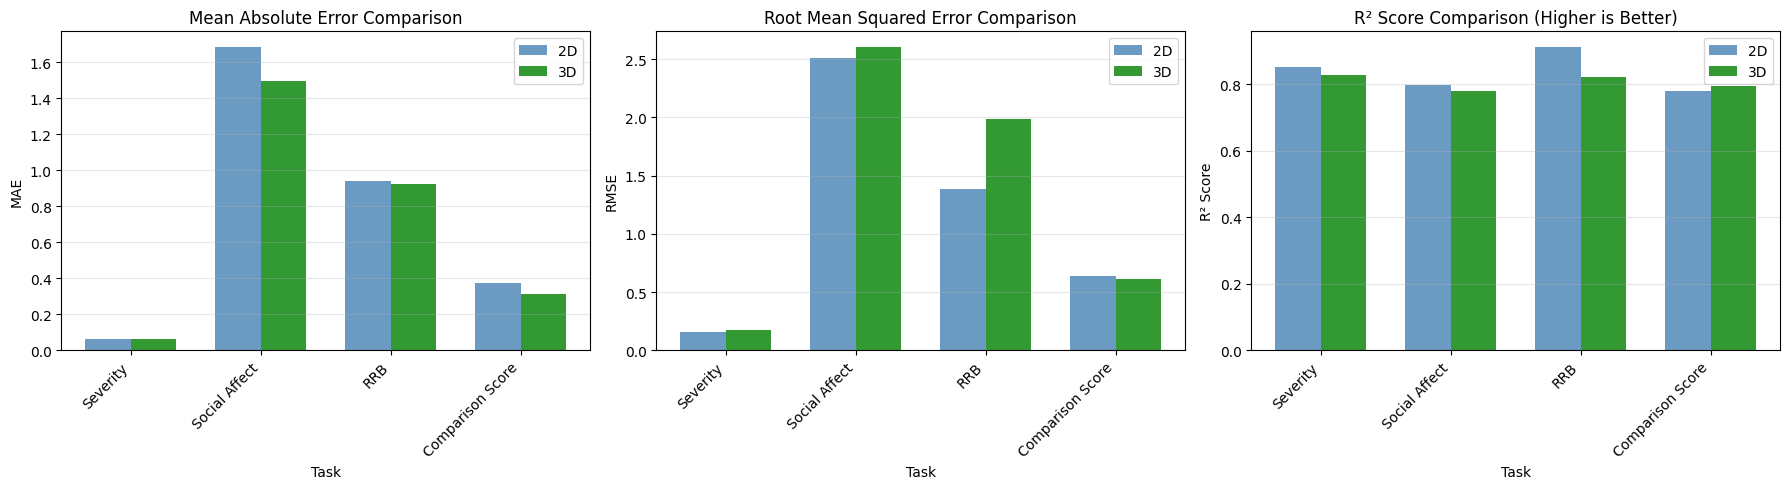


✅ Comparison visualization saved to '2d_vs_3d_comparison.png'
✅ Comparison table saved to '2d_vs_3d_comparison.csv'


In [31]:
# ========================
# Model Comparison: 2D vs 3D
# ========================
import matplotlib.pyplot as plt
import pandas as pd

print("\n" + "="*80)
print("COMPARISON: 2D MODEL vs 3D MODEL")
print("="*80)

# Compute metrics for both models
comparison_data = []

for i, task_name in enumerate(['Severity', 'Social Affect', 'RRB', 'Comparison Score']):
    # 2D model metrics
    mae_2d = mean_absolute_error(targets_original[:, i], preds_original[:, i])
    rmse_2d = np.sqrt(mean_squared_error(targets_original[:, i], preds_original[:, i]))
    r2_2d = r2_score(targets_original[:, i], preds_original[:, i])
    
    # 3D model metrics
    mae_3d = mean_absolute_error(targets_original_3d[:, i], preds_original_3d[:, i])
    rmse_3d = np.sqrt(mean_squared_error(targets_original_3d[:, i], preds_original_3d[:, i]))
    r2_3d = r2_score(targets_original_3d[:, i], preds_original_3d[:, i])
    
    comparison_data.append({
        'Task': task_name,
        '2D_MAE': mae_2d,
        '2D_RMSE': rmse_2d,
        '2D_R2': r2_2d,
        '3D_MAE': mae_3d,
        '3D_RMSE': rmse_3d,
        '3D_R2': r2_3d,
        'MAE_Improvement': ((mae_2d - mae_3d) / mae_2d) * 100,
        'RMSE_Improvement': ((rmse_2d - rmse_3d) / rmse_2d) * 100,
        'R2_Improvement': ((r2_3d - r2_2d) / abs(r2_2d)) * 100 if r2_2d != 0 else 0
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nDetailed Comparison:")
print("-" * 80)
for _, row in comparison_df.iterrows():
    print(f"\n{row['Task']}:")
    print(f"  2D Model - MAE: {row['2D_MAE']:.4f}, RMSE: {row['2D_RMSE']:.4f}, R²: {row['2D_R2']:.4f}")
    print(f"  3D Model - MAE: {row['3D_MAE']:.4f}, RMSE: {row['3D_RMSE']:.4f}, R²: {row['3D_R2']:.4f}")
    print(f"  Improvement - MAE: {row['MAE_Improvement']:+.2f}%, RMSE: {row['RMSE_Improvement']:+.2f}%, R²: {row['R2_Improvement']:+.2f}%")

# Overall comparison
print("\n" + "="*80)
print("OVERALL SUMMARY:")
print("-" * 80)
print(f"2D Model - Avg R²: {comparison_df['2D_R2'].mean():.4f}")
print(f"3D Model - Avg R²: {comparison_df['3D_R2'].mean():.4f}")
print(f"Average R² Improvement: {comparison_df['R2_Improvement'].mean():+.2f}%")
print("="*80)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tasks = comparison_df['Task'].values
x = np.arange(len(tasks))
width = 0.35

# MAE comparison
ax1 = axes[0]
ax1.bar(x - width/2, comparison_df['2D_MAE'], width, label='2D', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, comparison_df['3D_MAE'], width, label='3D', color='green', alpha=0.8)
ax1.set_xlabel('Task')
ax1.set_ylabel('MAE')
ax1.set_title('Mean Absolute Error Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(tasks, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# RMSE comparison
ax2 = axes[1]
ax2.bar(x - width/2, comparison_df['2D_RMSE'], width, label='2D', color='steelblue', alpha=0.8)
ax2.bar(x + width/2, comparison_df['3D_RMSE'], width, label='3D', color='green', alpha=0.8)
ax2.set_xlabel('Task')
ax2.set_ylabel('RMSE')
ax2.set_title('Root Mean Squared Error Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(tasks, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# R² comparison
ax3 = axes[2]
ax3.bar(x - width/2, comparison_df['2D_R2'], width, label='2D', color='steelblue', alpha=0.8)
ax3.bar(x + width/2, comparison_df['3D_R2'], width, label='3D', color='green', alpha=0.8)
ax3.set_xlabel('Task')
ax3.set_ylabel('R² Score')
ax3.set_title('R² Score Comparison (Higher is Better)')
ax3.set_xticks(x)
ax3.set_xticklabels(tasks, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('2d_vs_3d_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Comparison visualization saved to '2d_vs_3d_comparison.png'")

# Save comparison table
comparison_df.to_csv('2d_vs_3d_comparison.csv', index=False)
print("✅ Comparison table saved to '2d_vs_3d_comparison.csv'")